In [1]:
import os
import sys
import math
import random
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
from torch.distributions.normal import Normal
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import FlattenObservation, TransformAction
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

from rl_firm.abm.parameter import ModelParameters, FirmParameters, HouseholdParameters
from rl_firm.abm.firm import Firm, LearningFirm
from rl_firm.abm.household import Household
from rl_firm.abm.model import BaselineModel
from rl_firm.env import BaselineABMEnv, make_sb_env, make_custom_env, EVALUATION_SEEDS
from rl_firm.ppo_lstm_truncated import PPOAgent

In [2]:
def print_firm_info(firm):
    print(f'Class: {firm.__class__}')
    print(f'Status: {"Bankrupted" if firm.is_bankrupt else "Alive"}')
    print(f'Liquidity: {firm.liquidity}')
    print(f'Liquidity buffer: {firm.liquidity_buffer}')
    print(f'Inventory: {firm.inventories}')
    print(f'Wage rate: {firm.wage_rate}')
    print(f'Goods price: {firm.goods_price}')
    print(f'Employee count: {firm.employee_count}')
    print(f'Customer count: {firm.customer_count}')
    print(f'Last month demand: {firm.last_month_demand}')
    print(f'Last month revenue: {firm.last_month_revenue}')
    print(f'Last month profit: {firm.last_month_profit}')
    print(f'Profit ranking: {get_ranking(firm)}')

def load_model(seed):
    with open(f'../snapshots/abm_{seed}.pkl', 'rb') as f:
        print(f'Loading seed {seed}')
        return pickle.load(f)

In [3]:
def get_ranking(firm):
    return sorted(firm.model.firms,
                  key=lambda f: f.last_month_profit,
                  reverse=True).index(firm) + 1

def get_model_from_env(env):
    # Get the model from the wrapped model
    while True:
        if hasattr(env, '_model'):
            return env._model
        elif hasattr(env, 'env'):
            env = env.env
        else:
            raise Exception('Not ABM env')

In [4]:
def plot_stats(stats, marker='o', from_month=None, to_month=None):
    # ---------------- common numeric x-axis ----------------
    n         = len(next(iter(stats.values())))   # length of any list
    months    = list(range(1, n + 1))            # 1, 2, …, n
    
    # ---------------- quick FacetGrid version -------------
    long_df = (pd.DataFrame(stats, index=months)
               .rename_axis('month')
               .reset_index()
               .melt(id_vars='month',
                     var_name='metric',
                     value_name='value'))

    if from_month:
        long_df = long_df[long_df['month'] >= from_month]

    if to_month:
        long_df = long_df[long_df['month'] <= to_month]
    
    g = sns.relplot(kind='line',
                    data=long_df,
                    x='month', y='value',
                    col='metric', col_wrap=2,
                    height=2.5, aspect=5,
                    marker=marker,
                    facet_kws=dict(sharex=True, sharey=False))
    
    g.set_titles(col_template='{col_name}')       # cleaner titles
    g.fig.suptitle('Learning firm statistics by month (numeric)', y=1.02)
    plt.tight_layout()
    plt.show()

def download_plot(stats, marker='o', from_month=None, to_month=None):
    # ---------------- common numeric x-axis ----------------
    n         = len(next(iter(stats.values())))   # length of any list
    months    = list(range(1, n + 1))            # 1, 2, …, n
    
    # ---------------- quick FacetGrid version -------------
    long_df = (pd.DataFrame(stats, index=months)
               .rename_axis('month')
               .reset_index()
               .melt(id_vars='month',
                     var_name='metric',
                     value_name='value'))

    if from_month:
        long_df = long_df[long_df['month'] >= from_month]

    if to_month:
        long_df = long_df[long_df['month'] <= to_month]
    
    g = sns.relplot(kind='line',
                    data=long_df,
                    x='month', y='value',
                    col='metric', col_wrap=2,
                    height=2.5, aspect=5,
                    marker=marker,
                    facet_kws=dict(sharex=True, sharey=False))
    
    g.set_titles(col_template='{col_name}')       # cleaner titles
    g.fig.suptitle('Learning firm statistics by month (numeric)', y=1.02)
    plt.tight_layout()
    plt.savefig("chart.png", dpi=300, bbox_inches="tight")

In [5]:
MODEL_PATH = os.path.join(os.path.abspath(os.path.join('..')), 'results/model/lstm_truncated/2m_anneal.pt')
MODEL_PATH

'/Users/hieule/Projects/thesis/results/model/lstm_truncated/2m_anneal.pt'

In [6]:
def get_ranking(firm):
    return sorted(firm.model.firms,
                  key=lambda f: f.last_month_profit,
                  reverse=True).index(firm) + 1

def percentile_rank(a, x):
    a = np.asarray(a)
    if a.size == 0:
        raise ValueError("a must not be empty")
    below = np.sum(a < x)
    equal = np.sum(a == x)
    return 100.0 * (below + 0.5 * equal) / a.size

def simulate(years=100, seed=20):
    env = make_custom_env()()
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        # Firm stats
        'liquidity_buffers': [],
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'last_month_demands': [],
        'months_since_hire_failure': [],
        # RL stats
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': [],
        # Analysis stats
        'marginal_costs': [],
        'price_markups': [],
        'inventory_to_demand': [],
        'price_percentiles': [],
        'wage_percentiles': [],
        'profit_percentiles': [],
        'employee_percentiles': [],
        'customer_percentiles': [],
        'median_active_prices': [],
        'median_active_wages': [],
        'median_active_profits': [],
        'median_active_employees': [],
        'median_active_customers': [],
        'median_active_inventories': [],
        'active_firm_counts': [],
    }
    def collect_stats(action, reward):
        stats['liquidity_buffers'].append(learning_firm.liquidity_buffer)
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        stats['last_month_demands'].append(learning_firm.last_month_demand)
        stats['months_since_hire_failure'].append(learning_firm.months_since_hire_failure)
        # RL stats
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)
        # Analysis stats
        stats['marginal_costs'].append(learning_firm.marginal_cost)
        stats['price_markups'].append(np.nan if learning_firm.marginal_cost <= 0 else learning_firm.goods_price / learning_firm.marginal_cost)
        stats['inventory_to_demand'].append(
            np.nan if learning_firm.last_month_demand <= 0 else
            learning_firm.inventories / learning_firm.last_month_demand
        )

        active_firms = model.firms.select(lambda f: not f.is_bankrupt)
        stats['price_percentiles'].append(percentile_rank(active_firms.get('goods_price'), learning_firm.goods_price))
        stats['wage_percentiles'].append(percentile_rank(active_firms.get('wage_rate'), learning_firm.wage_rate))
        stats['profit_percentiles'].append(percentile_rank(active_firms.get('last_month_profit'), learning_firm.last_month_profit))
        stats['employee_percentiles'].append(percentile_rank(active_firms.get('employee_count'), learning_firm.employee_count))
        stats['customer_percentiles'].append(percentile_rank(active_firms.get('customer_count'), learning_firm.customer_count))
        stats['median_active_prices'].append(np.median(active_firms.get('goods_price')))
        stats['median_active_wages'].append(np.median(active_firms.get('wage_rate')))
        stats['median_active_profits'].append(np.median(active_firms.get('last_month_profit')))
        stats['median_active_employees'].append(np.median(active_firms.get('employee_count')))
        stats['median_active_customers'].append(np.median(active_firms.get('customer_count')))
        stats['median_active_inventories'].append(np.median(active_firms.get('inventories')))
        stats['active_firm_counts'].append(len(active_firms))
        

    custom_lstm_agent = PPOAgent(obs_dim=int(np.array(env.observation_space.shape).prod()))
    custom_lstm_agent.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
    custom_lstm_agent.eval()
    
    lstm_state = (torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size),
                  torch.zeros(custom_lstm_agent.lstm.num_layers, 1, custom_lstm_agent.lstm.hidden_size))
    done = torch.zeros(1)
    
    for _ in range(years * 12):
        action, lstm_state = custom_lstm_agent.predict(torch.Tensor(np.array([obs])), lstm_state, done, deterministic=True)
        action = {
            'hr_action': int(action['hr_action']),
            'price_adjustment': float(action['price_adjustment']),
            'wage_adjustment': float(action['wage_adjustment'])
        }
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        done = torch.Tensor(np.array([terminated]))
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break
    
    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')

    return stats, model

## 2m anneal truncated

In [8]:
stats, model = simulate(seed=20)

Loading seed 14
Loading seed 20
Firm survived for 100 years, making a total amount of 65020094.11402316 of profit, with total reward 138.91633528570605


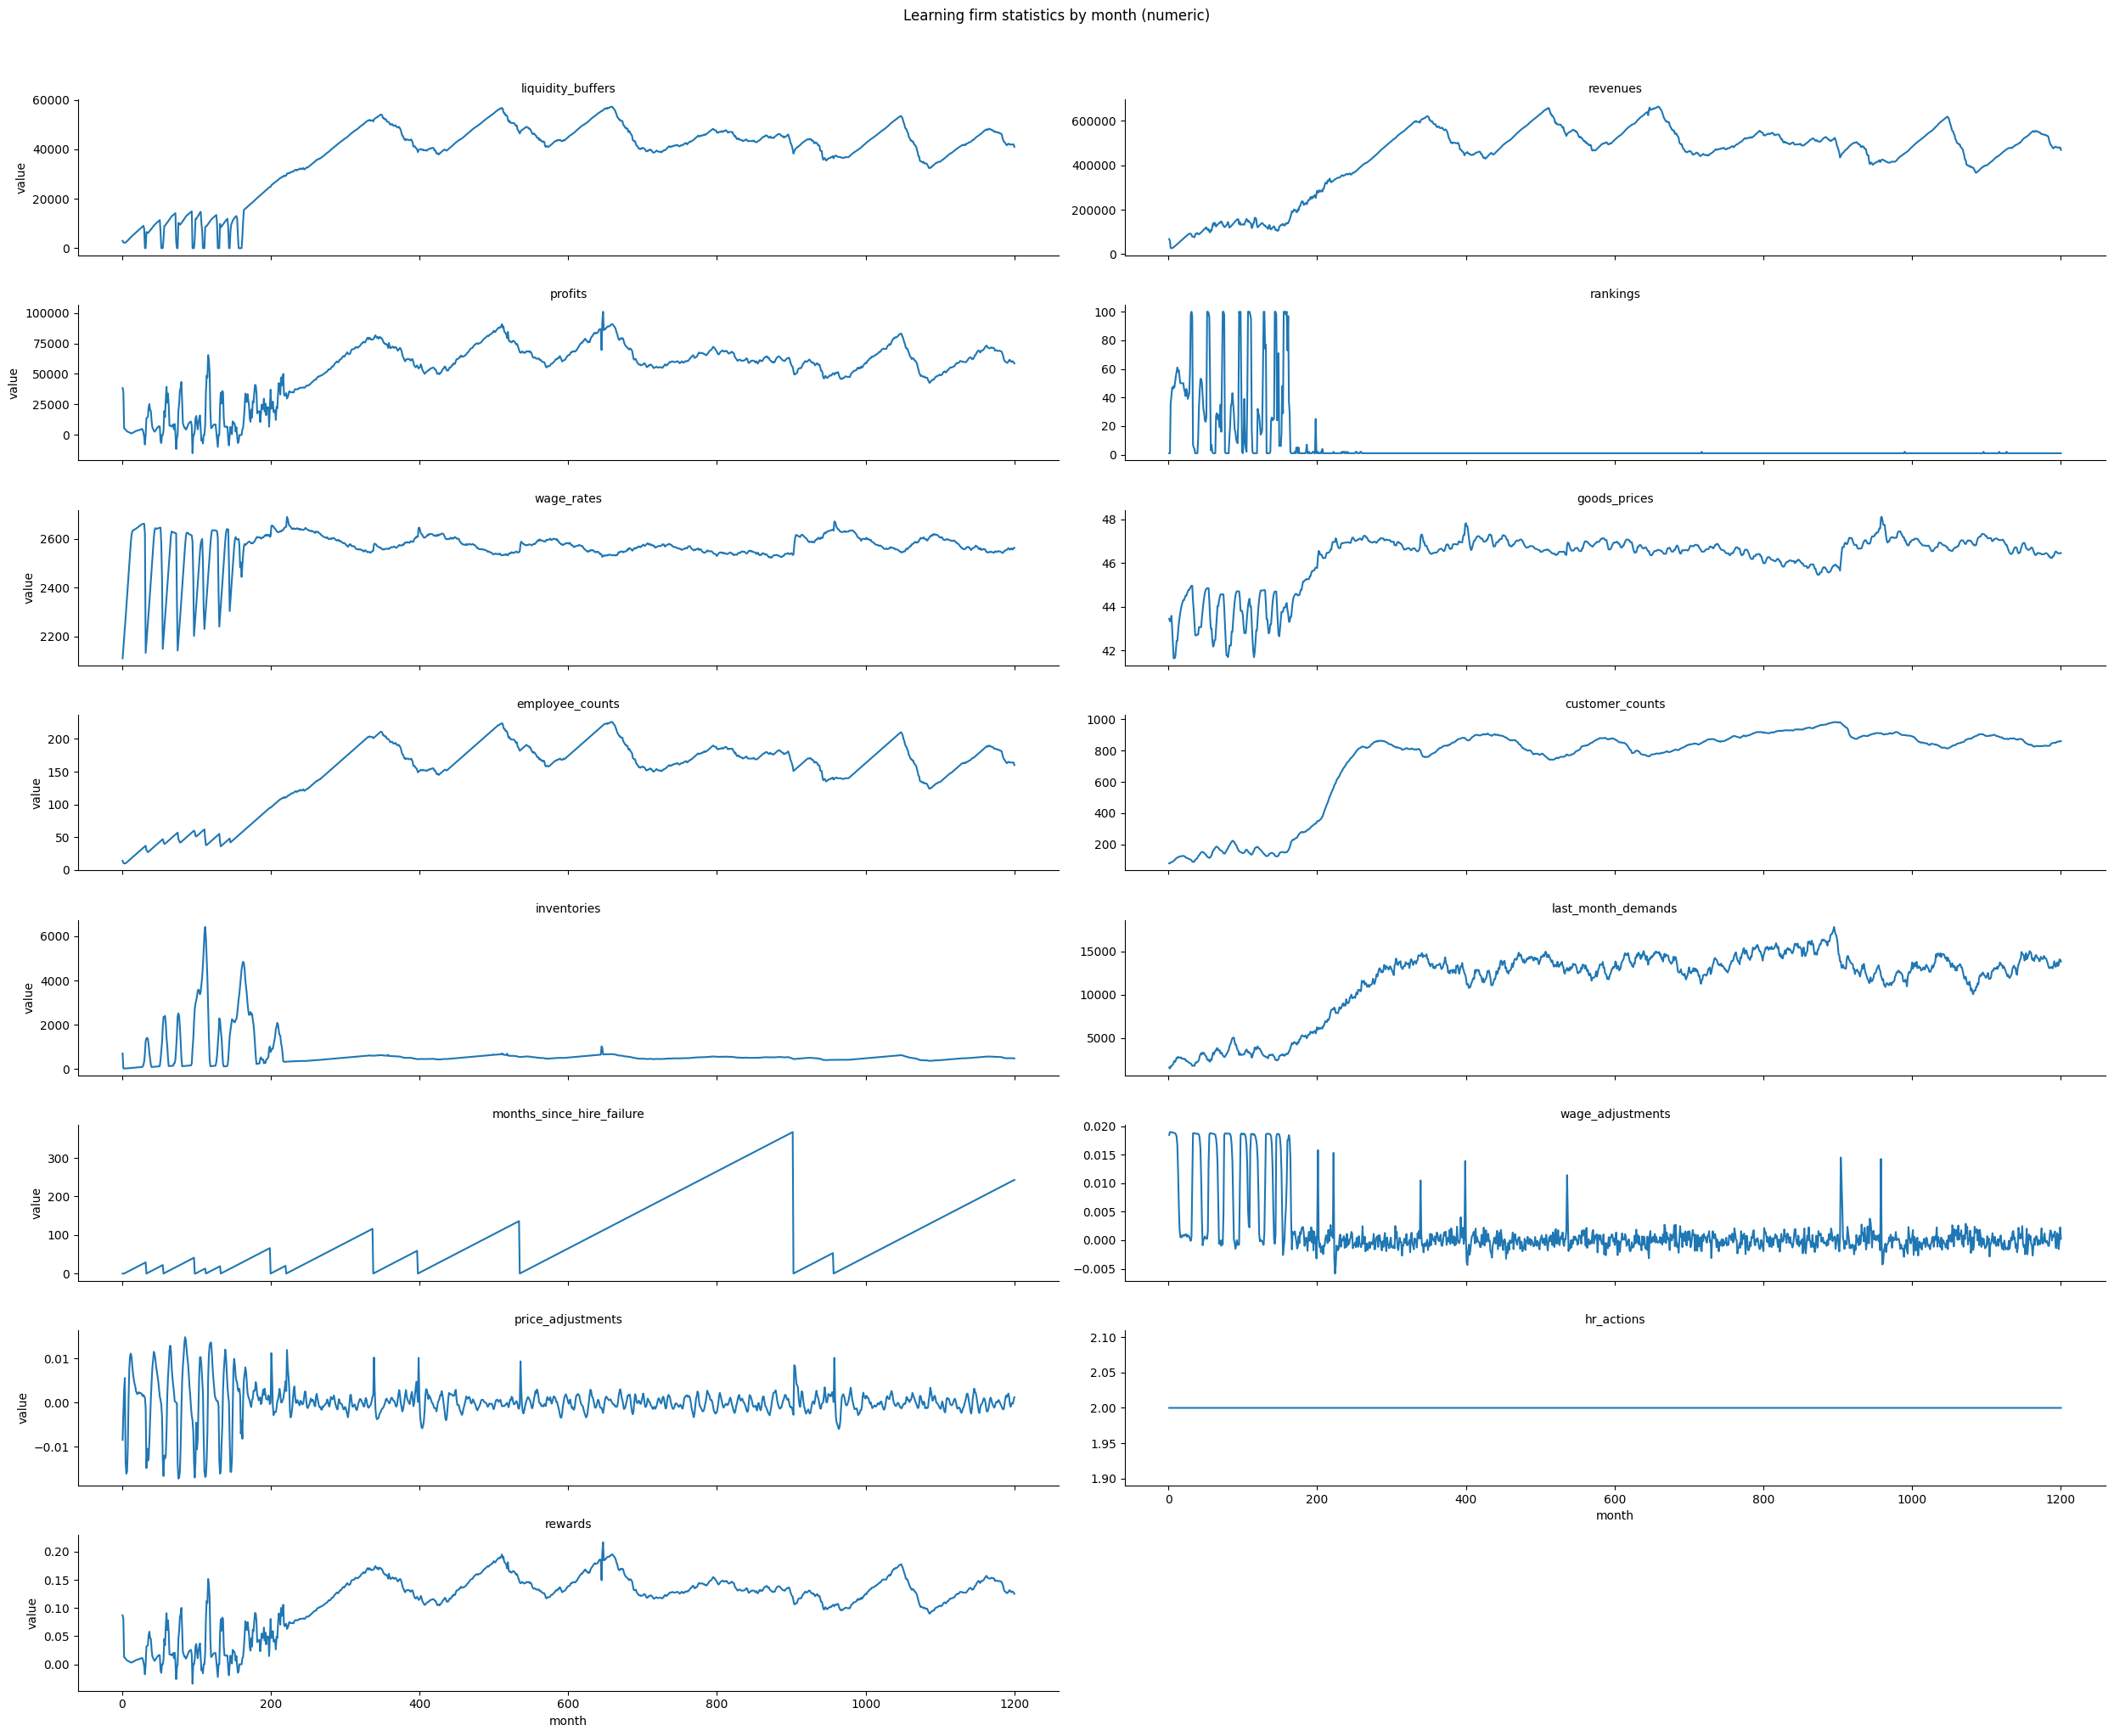

In [9]:
plot_stats(stats, marker='None')

## Run for all the evaluation seeds

In [7]:
stats, models = [], []
for seed in EVALUATION_SEEDS:
    stat, model = simulate(seed=seed)
    stats.append(stat)
    models.append(model)

Loading seed 4
Loading seed 20
Firm survived for 100 years, making a total amount of 65020094.11402316 of profit, with total reward 138.91633528570605
Loading seed 18
Loading seed 21
Firm survived for 100 years, making a total amount of 55175417.299739376 of profit, with total reward 118.11616984925463
Loading seed 12
Loading seed 22
Firm survived for 100 years, making a total amount of 41542866.86465268 of profit, with total reward 89.51898433212965
Loading seed 1
Loading seed 23
Firm survived for 100 years, making a total amount of 52525881.22511431 of profit, with total reward 113.00381235451312
Loading seed 4
Loading seed 24
Firm survived for 100 years, making a total amount of 54027779.66311136 of profit, with total reward 116.03194004525736
Loading seed 17
Loading seed 25
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 0.0 of profit, with total reward 0.0
Loading seed 14
Loading seed 26
Firm survived for 100 years, making a total amount of 57673458.8

## Immediate failure seed

In [8]:
model = load_model(33)
print_firm_info(model.firms[-1])

Loading seed 33
Class: <class 'firm.LearningFirm'>
Status: Bankrupted
Liquidity: 0.0
Liquidity buffer: 0.0
Inventory: 0.0
Wage rate: 948.2892533810257
Goods price: 45.32407835337479
Employee count: 0
Customer count: 3
Last month demand: 62.67256105795937
Last month revenue: 0.0
Last month profit: 0.0
Profit ranking: 99


## Representative analysis

In [7]:
TRANSIENT_CUTOFF = {20: 175, 21: 200, 22: 400, 23: 100, 24: 150,
                    26: 100, 27: 100, 29: 100,
                    30: None, 31: 100, 34: 100,
                    35: 75, 36: 150, 37: 75, 38: 125, 39: 225
}
STABLE_SEEDS = [20, 21, 22, 23, 24, 26, 27, 29, 31, 34, 35, 36, 37, 38, 39]

## SEED 36

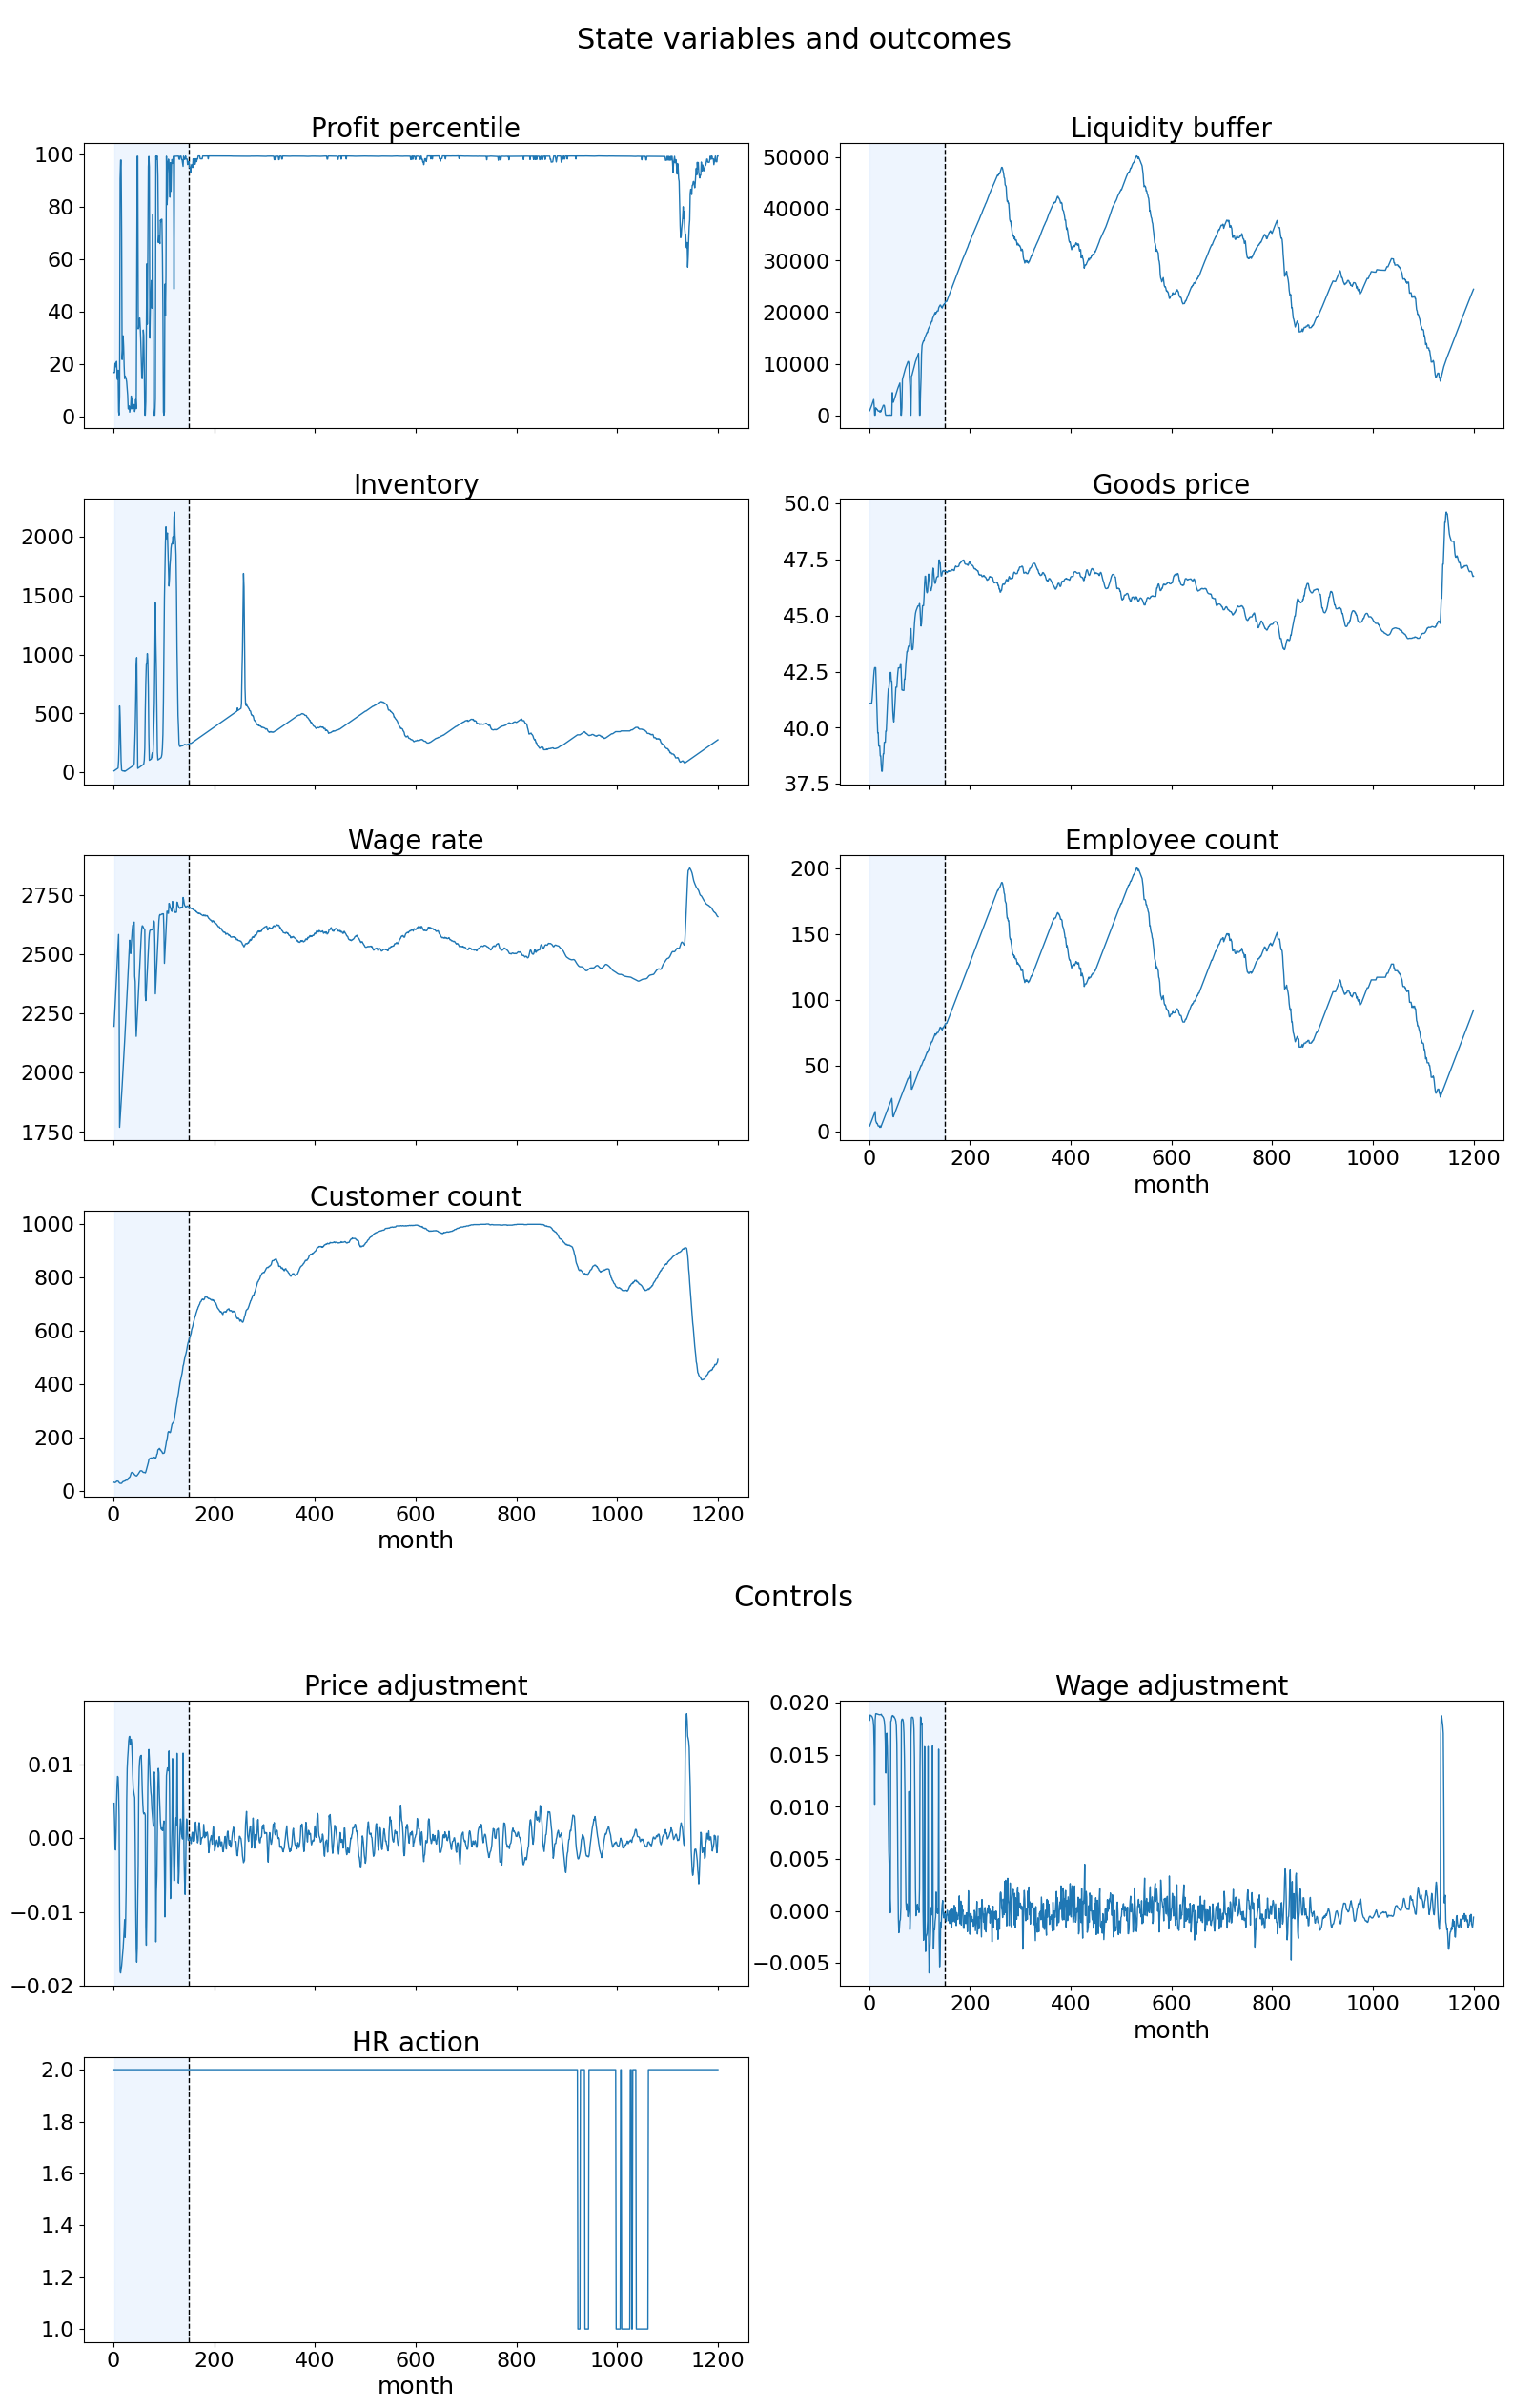

In [13]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


def plot_trajectories(
    stats,
    sections=None,
    metric_labels=None,         # dict: raw_name -> display name
    marker=None,
    from_month=None,
    to_month=None,
    col_wrap=2,
    panel_height=4.0,
    aspect=2.0,
    suptitle=None,
    transient_point=None,
    pre_color="#dbeafe",
    post_color=None,            # None = no shading for post-transient
    show_transient_note=False,
    download=False,
    filename='figure.png'
):
    # ---------------- data ----------------
    n = len(next(iter(stats.values())))
    months = list(range(1, n + 1))

    long_df = (
        pd.DataFrame(stats, index=months)
        .rename_axis("month")
        .reset_index()
        .melt(id_vars="month", var_name="metric", value_name="value")
    )

    if from_month is not None:
        long_df = long_df[long_df["month"] >= from_month]

    if to_month is not None:
        long_df = long_df[long_df["month"] <= to_month]

    all_metrics = list(long_df["metric"].unique())
    metric_labels = metric_labels or {}

    if sections is None:
        sections = {"Metrics": all_metrics}
    else:
        sections = {
            title: [m for m in metrics if m in all_metrics]
            for title, metrics in sections.items()
        }
        sections = {title: metrics for title, metrics in sections.items() if metrics}

    if not sections:
        raise ValueError("No valid metrics found in sections.")

    # ---------------- style ----------------
    plt.rcdefaults()
    plt.rcParams.update({
        "figure.titlesize": 28,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    })

    # ---------------- layout bookkeeping ----------------
    section_specs = []
    total_plot_rows = 0
    max_cols = 0

    for section_title, metrics in sections.items():
        ncols = min(col_wrap, len(metrics))
        nrows = math.ceil(len(metrics) / ncols)
        section_specs.append((section_title, metrics, nrows, ncols))
        total_plot_rows += nrows
        max_cols = max(max_cols, ncols)

    total_rows = total_plot_rows + len(section_specs)

    fig_width = max_cols * panel_height * aspect
    fig_height = total_plot_rows * panel_height + 0.55 * len(section_specs) + 0.8

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(
        total_rows,
        max_cols,
        figure=fig,
        height_ratios=[
            0.22 if row_is_title else 1.0
            for row_is_title in _title_row_mask(section_specs)
        ]
    )

    fig.suptitle(suptitle, y=0.995)

    # ---------------- draw ----------------
    current_row = 0
    first_ax = None

    x_min = long_df["month"].min()
    x_max = long_df["month"].max()

    for section_title, metrics, nrows, ncols in section_specs:
        title_ax = fig.add_subplot(gs[current_row, :])
        title_ax.axis("off")
        title_ax.text(
            0.5, 0.5, section_title,
            ha="center", va="center",
            fontsize=22
        )
        current_row += 1

        section_axes = []

        for i, metric in enumerate(metrics):
            r = i // ncols
            c = i % ncols

            ax = fig.add_subplot(
                gs[current_row + r, c],
                sharex=first_ax if first_ax is not None else None
            )

            if first_ax is None:
                first_ax = ax

            metric_df = long_df[long_df["metric"] == metric]

            if transient_point is not None:
                if transient_point > x_min:
                    ax.axvspan(x_min, transient_point, color=pre_color, alpha=0.45, zorder=0)
                if post_color is not None and transient_point < x_max:
                    ax.axvspan(transient_point, x_max, color=post_color, alpha=0.45, zorder=0)
                ax.axvline(transient_point, color="black", linestyle="--", linewidth=1, zorder=2)

            sns.lineplot(
                data=metric_df,
                x="month",
                y="value",
                marker=marker,
                linewidth=1,
                ax=ax,
                zorder=3,
            )

            display_name = metric_labels.get(metric, metric)
            ax.set_title(display_name, pad=4)
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

            section_axes.append(ax)

        # show x-axis on the last ncols visible charts in each section
        for ax in section_axes[max(0, len(metrics) - ncols):]:
            ax.set_xlabel("month")
            ax.tick_params(axis="x", labelbottom=True)

        # blank unused cells
        for j in range(len(metrics), nrows * ncols):
            r = j // ncols
            c = j % ncols
            blank_ax = fig.add_subplot(gs[current_row + r, c])
            blank_ax.axis("off")

        current_row += nrows

    if transient_point is not None and show_transient_note:
        fig.text(
            0.5, 0.01,
            f"Shaded region indicates the pre-transient period. "
            f"The dashed vertical line marks the transient point at month {transient_point}.",
            ha="center",
            va="bottom",
            fontsize=9
        )
        fig.tight_layout(rect=[0, 0.03, 1, 0.985])
    else:
        fig.tight_layout(rect=[0, 0, 1, 0.985])

    if download:
        plt.savefig(f'../imgs/{filename}', dpi=300, bbox_inches="tight")
    plt.show()


def _title_row_mask(section_specs):
    mask = []
    for _, _, nrows, _ in section_specs:
        mask.append(True)
        mask.extend([False] * nrows)
    return mask

sections = {
    "State variables and outcomes": [
        "profit_percentiles",
        "liquidity_buffers",
        "inventories",
        "goods_prices",
        "wage_rates",
        "employee_counts",
        "customer_counts",
    ],
    "Controls": [
        "price_adjustments",
        "wage_adjustments",
        "hr_actions",
    ],
}

metric_labels = {
    "profit_percentiles": "Profit percentile",
    "liquidity_buffers": "Liquidity buffer",
    "inventories": "Inventory",
    "goods_prices": "Goods price",
    "wage_rates": "Wage rate",
    "employee_counts": "Employee count",
    "customer_counts": "Customer count",
    "price_adjustments": "Price adjustment",
    "wage_adjustments": "Wage adjustment",
    "hr_actions": "HR action",
}

# First create the imgs folder
Path('../imgs').mkdir(parents=True, exist_ok=True)
plot_trajectories(
    stats[16],
    sections=sections,
    metric_labels=metric_labels,
    marker=None,
    panel_height=4.0,
    aspect=2.0,
    transient_point=150,
    show_transient_note=False,
    download=True,
    filename='fig_3.pdf'
)

In [283]:
max(stats[16]['customer_counts'])

999

In [287]:
np.std(stats[16]['wage_adjustments'][:150])

np.float64(0.009121184077627152)

In [288]:
np.std(stats[16]['wage_adjustments'][150:])

np.float64(0.0018168215109952582)

In [290]:
np.mean(stats[16]['wage_adjustments'][150:])

np.float64(-1.2691444939091092e-05)

## Seed 20, 22 and 30

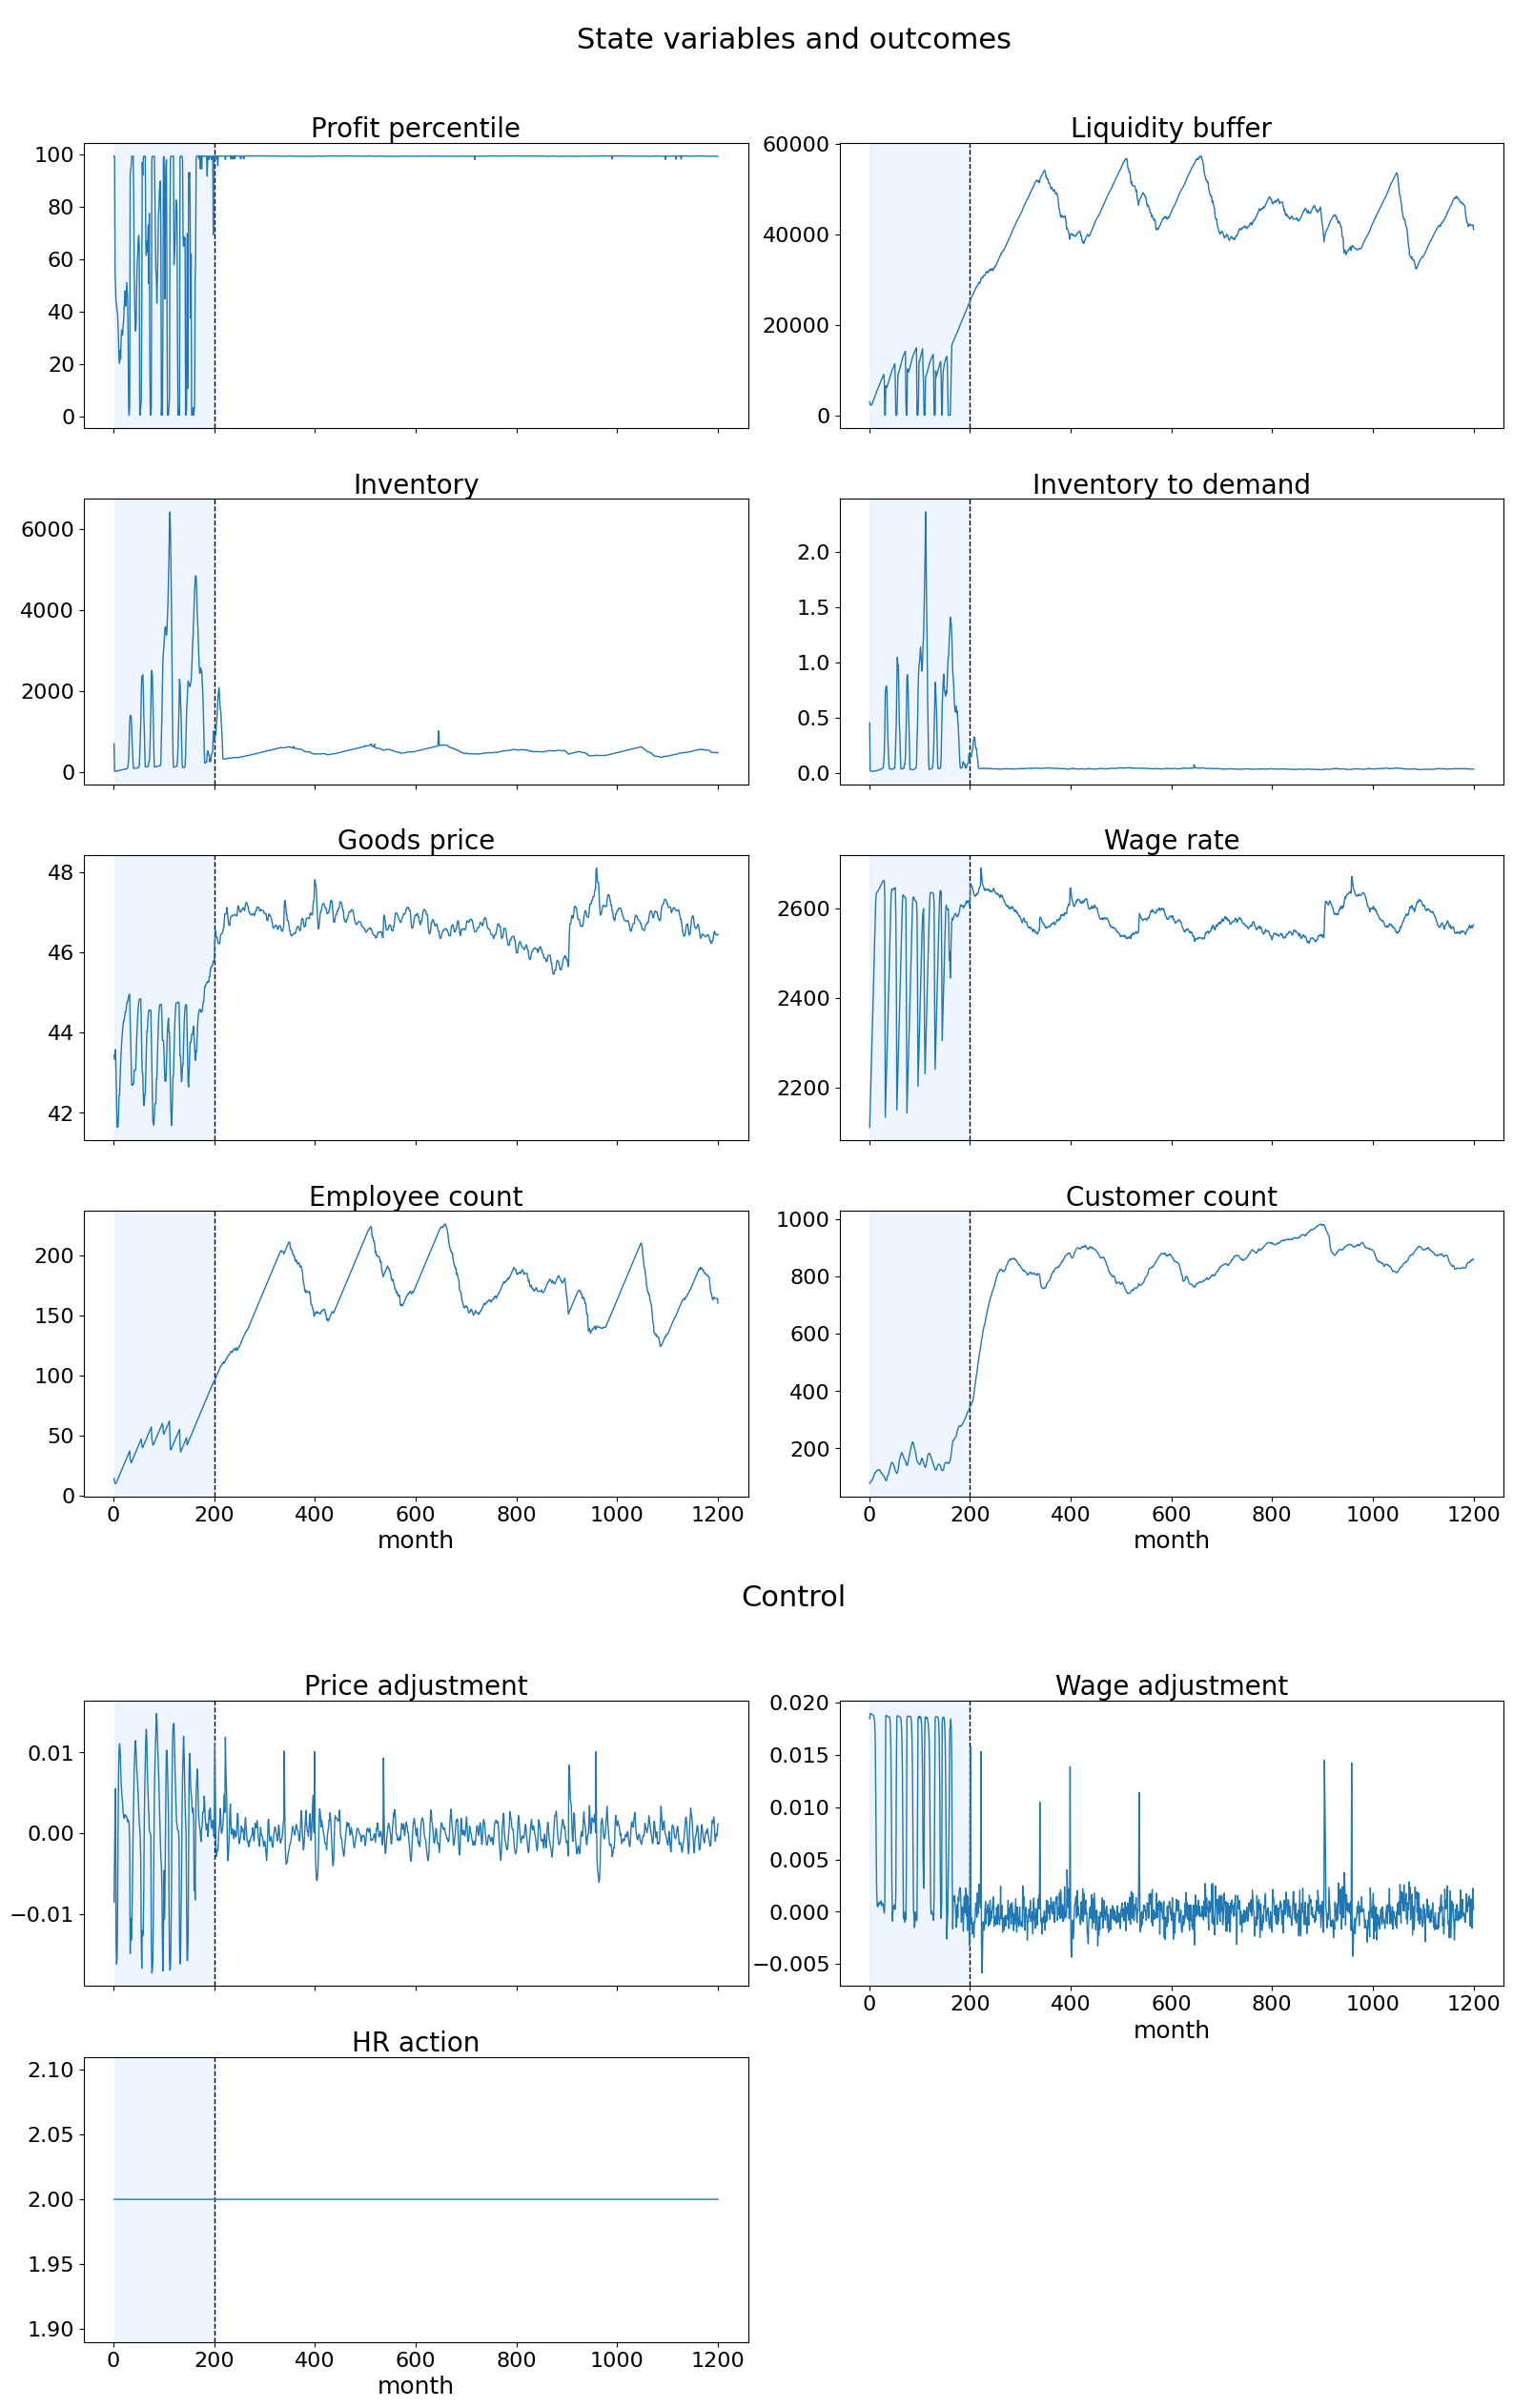

In [14]:
sections = {
    "State variables and outcomes": [
        "profit_percentiles",
        "liquidity_buffers",
        "inventories",
        "inventory_to_demand",
        "goods_prices",
        "wage_rates",
        "employee_counts",
        "customer_counts",
    ],
    "Control": [
        "price_adjustments",
        "wage_adjustments",
        "hr_actions",
    ],
}

metric_labels = {
    "profit_percentiles": "Profit percentile",
    "liquidity_buffers": "Liquidity buffer",
    "inventories": "Inventory",
    "inventory_to_demand": "Inventory to demand",
    "goods_prices": "Goods price",
    "wage_rates": "Wage rate",
    "employee_counts": "Employee count",
    "customer_counts": "Customer count",
    "price_adjustments": "Price adjustment",
    "wage_adjustments": "Wage adjustment",
    "hr_actions": "HR action",
}

plot_trajectories(
    stats[0],
    sections=sections,
    metric_labels=metric_labels,
    marker=None,
    panel_height=4.0,
    aspect=2.0,
    transient_point=200,
    show_transient_note=False,
    download=False,
    #filename='fig_3.pdf'
)

## COMPARE SEED 20, 22, 30

In [15]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


def plot_trajectories_compare(
    stats_list,
    seed_labels=None,
    sections=None,
    metric_labels=None,
    marker=None,
    from_month=None,
    to_month=None,
    col_wrap=2,
    panel_height=4.0,
    aspect=2.0,

    # titles
    suptitle="Learning firm statistics by month across seeds",
    show_suptitle=True,
    show_section_titles=True,
    show_metric_titles=True,

    # transient annotations
    transient_points=None,          # shared points, drawn in black
    seed_transient_points=None,     # dict: seed label -> list of points, drawn in seed color
    show_transient_lines=True,
    shade_regions=False,
    region_colors=None,
    show_transient_note=False,

    # legend
    show_legend=True,

    # download
    download=False,
    filename="fig.png"
):
    if not stats_list:
        raise ValueError("stats_list must contain at least one stats dict.")

    metric_labels = metric_labels or {}

    if seed_labels is None:
        seed_labels = [f"Seed {i+1}" for i in range(len(stats_list))]

    if len(seed_labels) != len(stats_list):
        raise ValueError("seed_labels must have the same length as stats_list.")

    transient_points = sorted(transient_points or [])
    seed_transient_points = seed_transient_points or {}

    # ---------------- build long dataframe ----------------
    long_parts = []

    for seed_idx, stats in enumerate(stats_list):
        n = len(next(iter(stats.values())))
        months = list(range(1, n + 1))

        df = (
            pd.DataFrame(stats, index=months)
            .rename_axis("month")
            .reset_index()
            .melt(id_vars="month", var_name="metric", value_name="value")
        )
        df["seed"] = seed_labels[seed_idx]
        long_parts.append(df)

    long_df = pd.concat(long_parts, ignore_index=True)

    if from_month is not None:
        long_df = long_df[long_df["month"] >= from_month]

    if to_month is not None:
        long_df = long_df[long_df["month"] <= to_month]

    all_metrics = list(long_df["metric"].unique())

    if sections is None:
        sections = {"Metrics": all_metrics}
    else:
        sections = {
            title: [m for m in metrics if m in all_metrics]
            for title, metrics in sections.items()
        }
        sections = {title: metrics for title, metrics in sections.items() if metrics}

    if not sections:
        raise ValueError("No valid metrics found in sections.")

    # ---------------- style ----------------
    plt.rcdefaults()
    plt.rcParams.update({
        "figure.titlesize": 28,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 18,
    })

    palette = sns.color_palette(n_colors=len(seed_labels))
    seed_color_map = dict(zip(seed_labels, palette))

    # ---------------- layout bookkeeping ----------------
    section_specs = []
    total_plot_rows = 0
    max_cols = 0

    for section_title, metrics in sections.items():
        ncols = min(col_wrap, len(metrics))
        nrows = math.ceil(len(metrics) / ncols)
        section_specs.append((section_title, metrics, nrows, ncols))
        total_plot_rows += nrows
        max_cols = max(max_cols, ncols)

    title_row_count = len(section_specs) if show_section_titles else 0
    total_rows = total_plot_rows + title_row_count

    fig_width = max_cols * panel_height * aspect
    fig_height = total_plot_rows * panel_height + (0.55 * title_row_count) + 1.0

    fig = plt.figure(figsize=(fig_width, fig_height))

    if show_section_titles:
        height_ratios = [
            0.22 if row_is_title else 1.0
            for row_is_title in _title_row_mask(section_specs)
        ]
    else:
        height_ratios = [1.0] * total_rows

    gs = GridSpec(
        total_rows,
        max_cols,
        figure=fig,
        height_ratios=height_ratios
    )

    if show_suptitle:
        fig.suptitle(suptitle, y=0.995)

    x_min = long_df["month"].min()
    x_max = long_df["month"].max()

    if region_colors is None:
        region_colors = ["#dbeafe", "#f3f4f6"]

    def draw_shared_regions(ax):
        if not shade_regions or not transient_points:
            return

        bounds = [x_min] + [p for p in transient_points if x_min < p < x_max] + [x_max]
        for i in range(len(bounds) - 1):
            left = bounds[i]
            right = bounds[i + 1]
            color = region_colors[i % len(region_colors)]
            ax.axvspan(left, right, color=color, alpha=0.25, zorder=0)

    def draw_shared_transient_lines(ax):
        if not show_transient_lines:
            return

        for p in transient_points:
            if x_min <= p <= x_max:
                ax.axvline(
                    p,
                    color="black",
                    linestyle="--",
                    linewidth=0.9,
                    zorder=1
                )

    def draw_seed_transient_lines(ax):
        if not show_transient_lines:
            return

        for seed, points in seed_transient_points.items():
            color = seed_color_map.get(seed, "black")
            for p in points:
                if x_min <= p <= x_max:
                    ax.axvline(
                        p,
                        color=color,
                        linestyle="--",
                        linewidth=1.0,
                        alpha=0.9,
                        zorder=1
                    )

    # ---------------- draw ----------------
    current_row = 0
    first_ax = None
    legend_handles = None
    legend_labels = None

    for section_title, metrics, nrows, ncols in section_specs:
        if show_section_titles:
            title_ax = fig.add_subplot(gs[current_row, :])
            title_ax.axis("off")
            title_ax.text(
                0.5, 0.5, section_title,
                ha="center", va="center",
                fontsize=22
            )
            current_row += 1

        section_axes = []

        for i, metric in enumerate(metrics):
            r = i // ncols
            c = i % ncols

            ax = fig.add_subplot(
                gs[current_row + r, c],
                sharex=first_ax if first_ax is not None else None
            )

            if first_ax is None:
                first_ax = ax

            metric_df = long_df[long_df["metric"] == metric]

            draw_shared_regions(ax)
            draw_shared_transient_lines(ax)
            draw_seed_transient_lines(ax)

            sns.lineplot(
                data=metric_df,
                x="month",
                y="value",
                hue="seed",
                marker=marker,
                linewidth=1,
                ax=ax,
                legend=True,
                palette=seed_color_map,
            )

            handles, labels = ax.get_legend_handles_labels()
            if handles and labels and legend_handles is None:
                legend_handles, legend_labels = handles, labels
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

            display_name = metric_labels.get(metric, metric.replace("_", " ").title())
            if show_metric_titles:
                ax.set_title(display_name, pad=4)
            else:
                ax.set_title("")

            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

            section_axes.append(ax)

        for ax in section_axes[max(0, len(metrics) - ncols):]:
            ax.set_xlabel("month")
            ax.tick_params(axis="x", labelbottom=True)

        for j in range(len(metrics), nrows * ncols):
            r = j // ncols
            c = j % ncols
            blank_ax = fig.add_subplot(gs[current_row + r, c])
            blank_ax.axis("off")

        current_row += nrows

    if show_legend and legend_handles is not None:
        legend_y = 0.975 if show_suptitle else 0.995
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=len(seed_labels),
            bbox_to_anchor=(0.5, legend_y),
            frameon=False,
        )

    if show_transient_note and (transient_points or seed_transient_points):
        note_parts = []

        if shade_regions and transient_points:
            note_parts.append("Alternating shaded regions indicate successive time regimes")

        if transient_points:
            if len(transient_points) == 1:
                note_parts.append(
                    f"black dashed line marks the shared transient point at month {transient_points[0]}"
                )
            else:
                points_str = ", ".join(str(p) for p in transient_points)
                note_parts.append(
                    f"black dashed lines mark shared transient points at months {points_str}"
                )

        if seed_transient_points:
            note_parts.append("colored dashed lines mark seed-specific transient points")

        note = ". ".join(note_parts) + "."
        fig.text(0.5, 0.01, note, ha="center", va="bottom", fontsize=9)
        top_rect = 0.94 if (show_suptitle or show_legend) else 0.985
        fig.tight_layout(rect=[0, 0.03, 1, top_rect])
    else:
        top_rect = 0.94 if (show_suptitle or show_legend) else 0.985
        fig.tight_layout(rect=[0, 0, 1, top_rect])

    if download:
        plt.savefig(f'../imgs/{filename}', dpi=300, bbox_inches="tight")
    plt.show()


def _title_row_mask(section_specs):
    mask = []
    for _, _, nrows, _ in section_specs:
        mask.append(True)
        mask.extend([False] * nrows)
    return mask

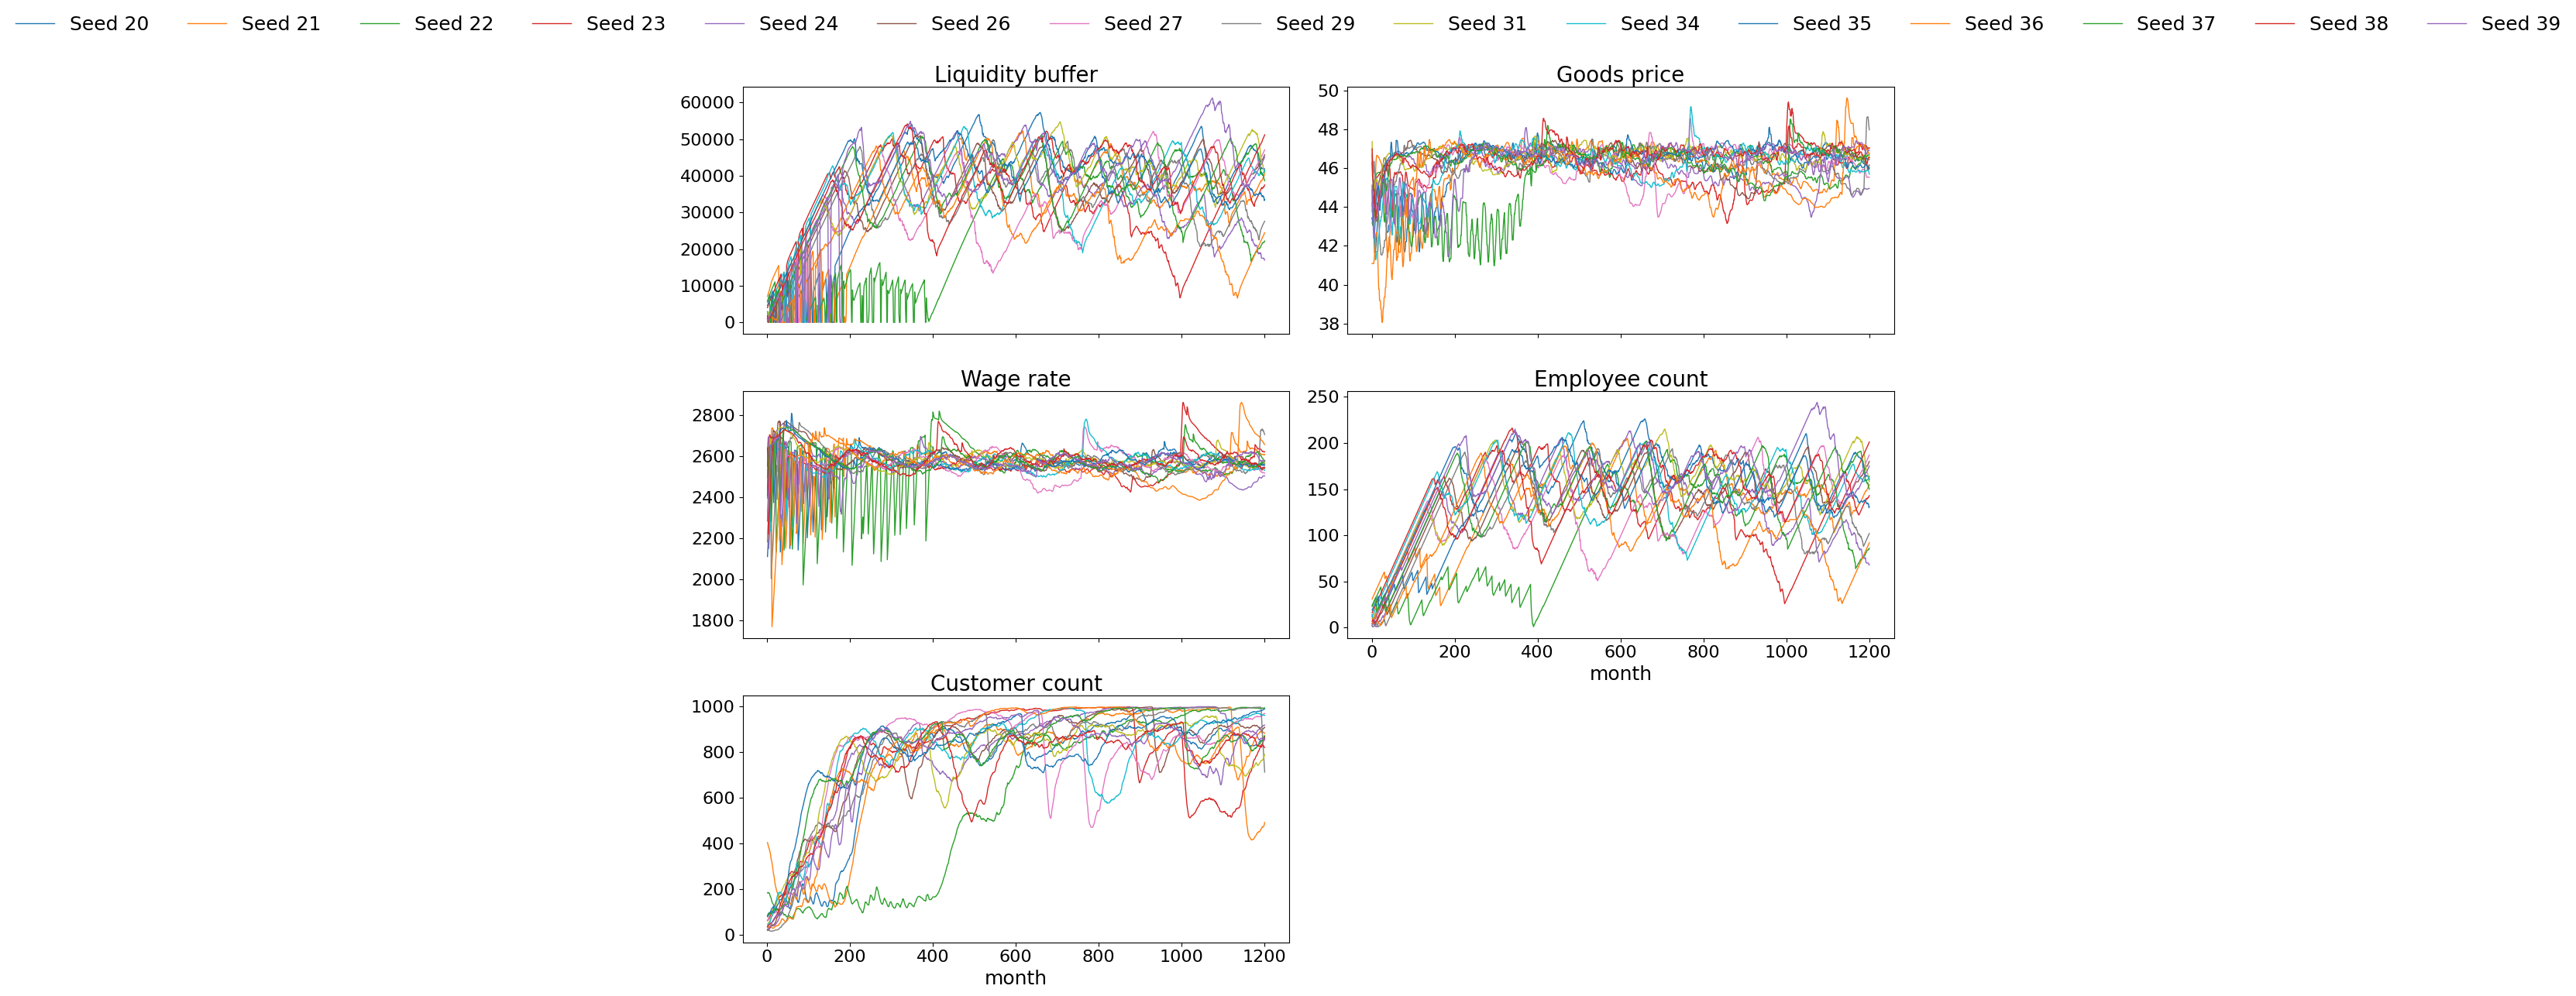

In [14]:
sections = {
    "State variables and outcome": [
        "liquidity_buffers",
        "goods_prices",
        "wage_rates",
        "employee_counts",
        "customer_counts",
    ],
}

metric_labels = {
    "profit_percentiles": "Profit percentile among active firms",
    "liquidity_buffers": "Liquidity buffer",
    "goods_prices": "Goods price",
    "wage_rates": "Wage rate",
    "employee_counts": "Employee count",
    "customer_counts": "Customer count",
    "price_adjustments": "Price adjustment",
    "wage_adjustments": "Wage adjustment",
    "hr_actions": "HR action",
}

plot_trajectories_compare(
    stats_list=[stats[i-20] for i in [20, 21, 22, 23, 24, 26, 27, 29, 31, 34, 35, 36, 37, 38, 39]],
    seed_labels=[f'Seed {i}' for i in [20, 21, 22, 23, 24, 26, 27, 29, 31, 34, 35, 36, 37, 38, 39]],
    sections=sections,
    metric_labels=metric_labels,
    seed_transient_points={},
    show_suptitle=False,
    show_section_titles=False,
    download=True,
    filename="compare_all.png"
)

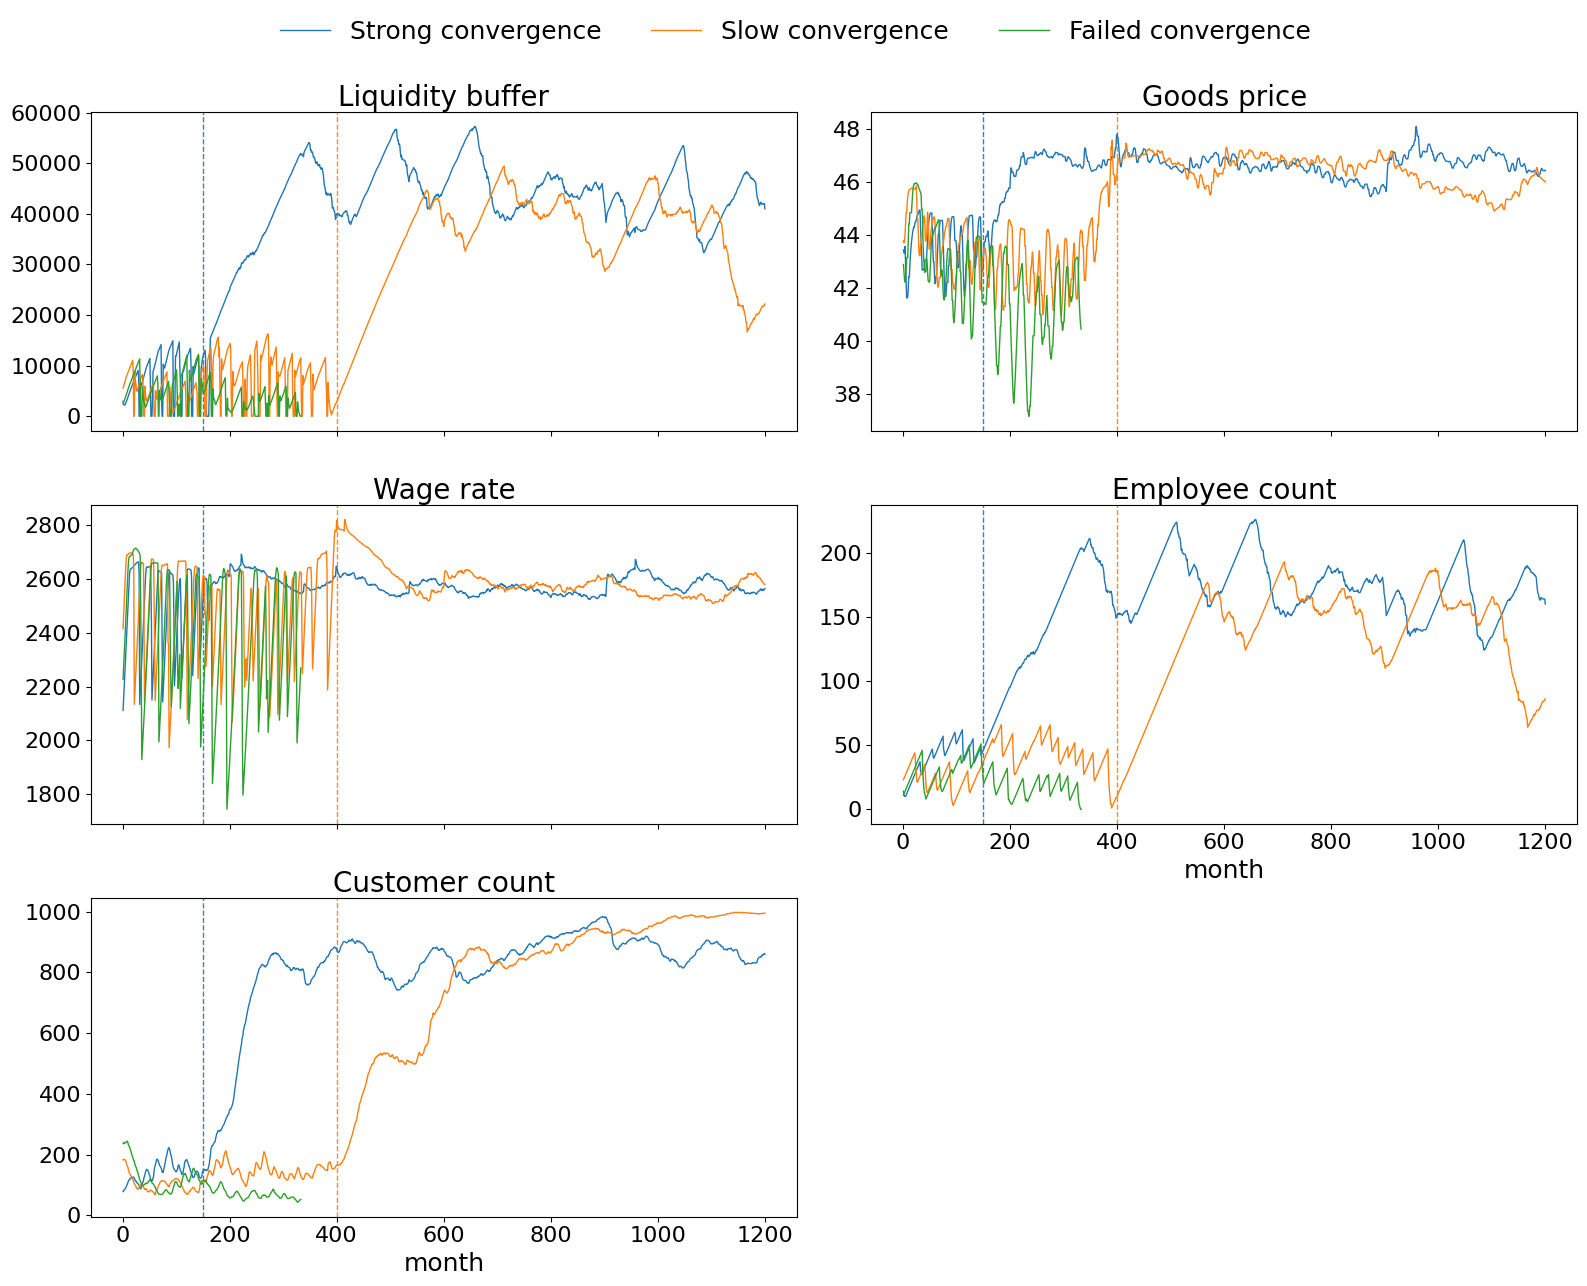

In [18]:
stats_list = [stats[0], stats[2], stats[10]]
seed_labels = []

sections = {
    "State variables and outcome": [
        "liquidity_buffers",
        "goods_prices",
        "wage_rates",
        "employee_counts",
        "customer_counts",
    ],
}

metric_labels = {
    "profit_percentiles": "Profit percentile among active firms",
    "liquidity_buffers": "Liquidity buffer",
    "goods_prices": "Goods price",
    "wage_rates": "Wage rate",
    "employee_counts": "Employee count",
    "customer_counts": "Customer count",
    "price_adjustments": "Price adjustment",
    "wage_adjustments": "Wage adjustment",
    "hr_actions": "HR action",
}

plot_trajectories_compare(
    stats_list=[stats[0], stats[2], stats[10]],
    seed_labels=["Strong convergence", "Slow convergence", "Failed convergence"],
    sections=sections,
    metric_labels=metric_labels,
    seed_transient_points={
        "Strong convergence": [150],
        "Slow convergence": [400],
    },
    show_suptitle=False,
    show_section_titles=False,
)

## Comparison with other baseline firms in the market

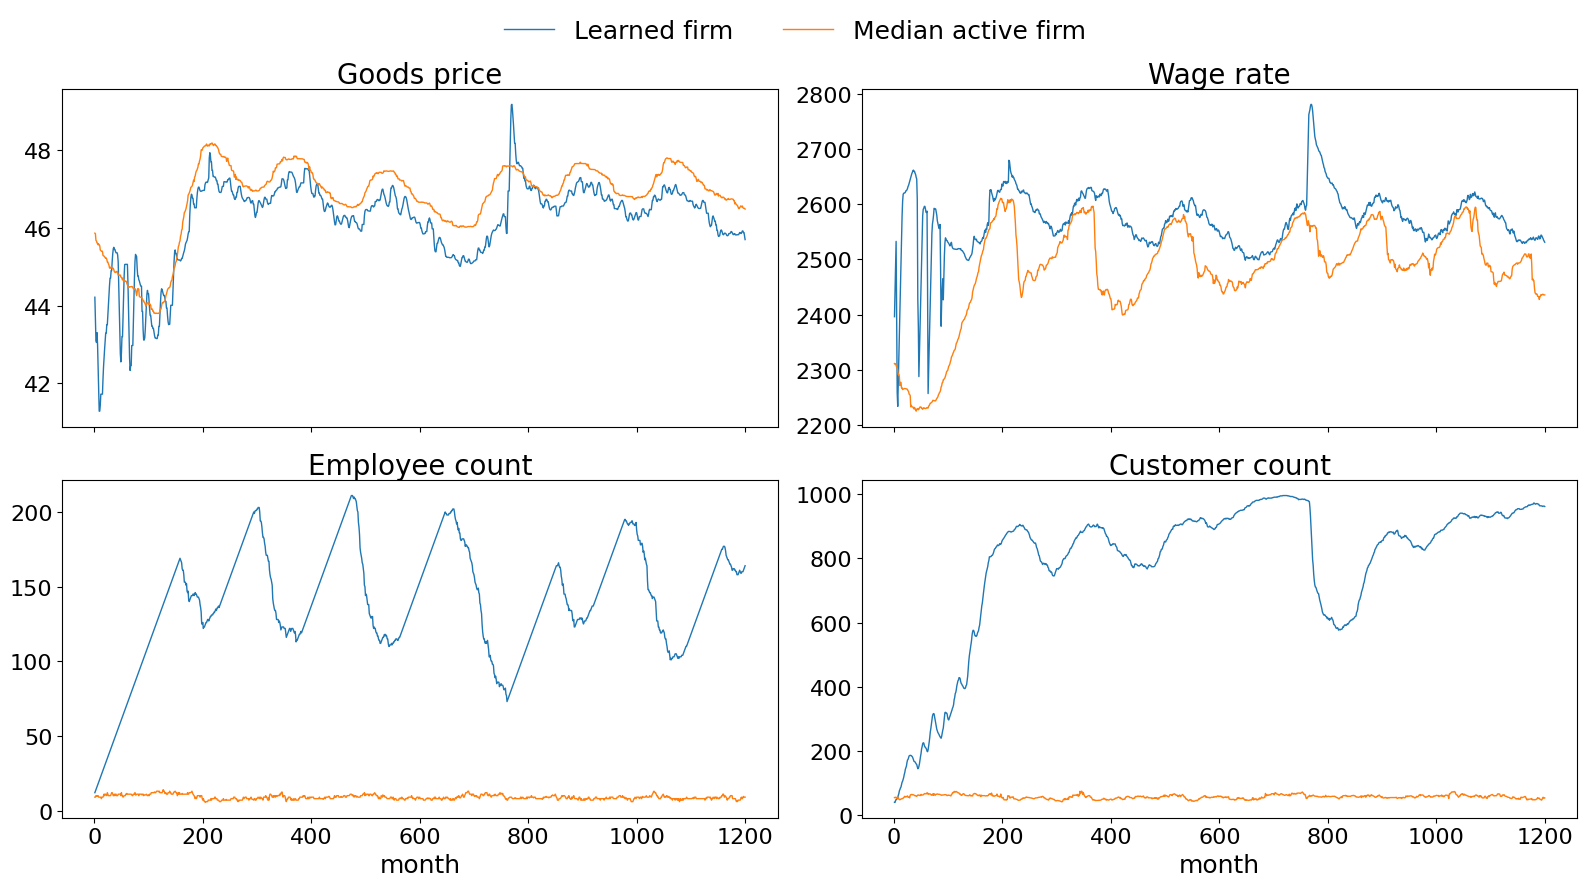

In [41]:
comparing_seed = 14
sections = {
    "State variables and outcome": [
        #"inventories",
        "goods_prices",
        "wage_rates",
        "employee_counts",
        "customer_counts",
    ],
}

plot_trajectories_compare(
    stats_list=[stats[comparing_seed], {
        "inventories": stats[comparing_seed]['median_active_inventories'],
        "goods_prices": stats[comparing_seed]['median_active_prices'],
        "wage_rates": stats[comparing_seed]['median_active_wages'],
        "employee_counts": stats[comparing_seed]['median_active_employees'],
        "customer_counts": stats[comparing_seed]['median_active_customers'],
    }],
    seed_labels=["Learned firm", "Median active firm"],
    sections=sections,
    metric_labels=metric_labels,
    show_suptitle=False,
    show_section_titles=False,
    download=True,
    filename="fig_5.pdf"
)

## Comparison with baseline firms

In [16]:
def baseline_simulate(years=100, seed=20):
    env = BaselineABMEnv()
    obs, info = env.reset(seed=seed)
    model = get_model_from_env(env)
    parameters = model.parameters
    learning_firm = model.learning_firms[0]
    stats = {
        # Firm stats
        'liquidity_buffers': [],
        'revenues': [],
        'profits': [],
        'rankings': [],
        'wage_rates': [],
        'goods_prices': [],
        'employee_counts': [],
        'customer_counts': [],
        'inventories': [],
        'last_month_demands': [],
        'months_since_hire_failure': [],
        # RL stats
        'wage_adjustments': [],
        'price_adjustments': [],
        'hr_actions': [],
        'rewards': [],
        # Analysis stats
        'marginal_costs': [],
        'price_markups': [],
        'inventory_to_demand': [],
        'price_percentiles': [],
        'wage_percentiles': [],
        'profit_percentiles': [],
        'employee_percentiles': [],
        'customer_percentiles': [],
        'median_active_prices': [],
        'median_active_wages': [],
        'median_active_profits': [],
        'median_active_employees': [],
        'median_active_customers': [],
        'active_firm_counts': [],
    }
    def collect_stats(action, reward):
        stats['liquidity_buffers'].append(learning_firm.liquidity_buffer)
        stats['revenues'].append(learning_firm.last_month_revenue)
        stats['profits'].append(learning_firm.last_month_profit)
        stats['rankings'].append(get_ranking(learning_firm))
        stats['wage_rates'].append(learning_firm.wage_rate)
        stats['goods_prices'].append(learning_firm.goods_price)
        stats['employee_counts'].append(learning_firm.employee_count)
        stats['customer_counts'].append(learning_firm.customer_count)
        stats['inventories'].append(learning_firm.inventories)
        stats['last_month_demands'].append(learning_firm.last_month_demand)
        stats['months_since_hire_failure'].append(learning_firm.months_since_hire_failure)
        # RL stats
        if 'hr_action' in action:
            stats['hr_actions'].append(int(np.clip(np.round(action['hr_action']), 0, 2)))
            stats['price_adjustments'].append(action['price_adjustment'])
            stats['wage_adjustments'].append(action['wage_adjustment'])
        else:
            stats['hr_actions'].append(int(np.clip(np.round(action[0]), 0, 2)))
            stats['price_adjustments'].append(action[1])
            stats['wage_adjustments'].append(action[2])
        stats['rewards'].append(reward)
        # Analysis stats
        stats['marginal_costs'].append(learning_firm.marginal_cost)
        stats['price_markups'].append(np.nan if learning_firm.marginal_cost <= 0 else learning_firm.goods_price / learning_firm.marginal_cost)
        stats['inventory_to_demand'].append(
            np.nan if learning_firm.last_month_demand <= 0 else
            learning_firm.inventories / learning_firm.last_month_demand
        )

        active_firms = model.firms.select(lambda f: not f.is_bankrupt)
        stats['price_percentiles'].append(percentile_rank(active_firms.get('goods_price'), learning_firm.goods_price))
        stats['wage_percentiles'].append(percentile_rank(active_firms.get('wage_rate'), learning_firm.wage_rate))
        stats['profit_percentiles'].append(percentile_rank(active_firms.get('last_month_profit'), learning_firm.last_month_profit))
        stats['employee_percentiles'].append(percentile_rank(active_firms.get('employee_count'), learning_firm.employee_count))
        stats['customer_percentiles'].append(percentile_rank(active_firms.get('customer_count'), learning_firm.customer_count))
        stats['median_active_prices'].append(np.median(active_firms.get('goods_price')))
        stats['median_active_wages'].append(np.median(active_firms.get('wage_rate')))
        stats['median_active_profits'].append(np.median(active_firms.get('last_month_profit')))
        stats['median_active_employees'].append(np.median(active_firms.get('employee_count')))
        stats['median_active_customers'].append(np.median(active_firms.get('customer_count')))
        stats['active_firm_counts'].append(len(active_firms))

    # Need to use the random of the agent in here for consistency
    def create_baseline_predictor():
        def predict_baseline(obs):
            wage_adjustment = 0
            # check if there was a open position last month (not fulfilled)
            if obs['open_position']:
                wage_adjustment = learning_firm.random.uniform(0, parameters.firm.delta_wage_adjustment_rate)
            
            # check if should decrease wage
            if obs['months_since_hire_failure'] >= parameters.firm.gamma_consecutive_months:
                wage_adjustment = - learning_firm.random.uniform(0, parameters.firm.delta_wage_adjustment_rate)
        
            price_adjustment = 0
            # Only set new price with probs theta_probs_set_new_price
            if learning_firm.random.random() < parameters.firm.theta_probs_set_new_price:
                # Consider increasing price if not enough inventories
                marginal_cost = obs['wage_rate'] / (parameters.firm.lambda_technology * parameters.month_length)
                if (obs['inventories'] < parameters.firm.lower_phi_demand * obs['last_month_demand'] and
                    obs['goods_price'] <= parameters.firm.upper_phi_marginal_cost * marginal_cost):
                    price_adjustment = learning_firm.random.uniform(0, parameters.firm.theta_goods_price)
            
                # Else consider reducing the price
                if (obs['inventories'] > parameters.firm.upper_phi_demand * obs['last_month_demand'] and
                    obs['goods_price'] >= parameters.firm.lower_phi_marginal_cost * marginal_cost):
                    price_adjustment = - learning_firm.random.uniform(0, parameters.firm.theta_goods_price)
            
            hr_action = 1
            # check if need to hire more
            if obs['inventories'] < parameters.firm.lower_phi_demand * obs['last_month_demand']:
                hr_action = 2
            # or check if need to put someone on notice
            elif obs['inventories'] > parameters.firm.upper_phi_demand * obs['last_month_demand'] and obs['employee_count'] > 0:
                hr_action = 0
        
            return {
                'hr_action': hr_action,
                'price_adjustment': price_adjustment,
                'wage_adjustment': wage_adjustment
            }
    
        return predict_baseline

    predict_baseline = create_baseline_predictor()
    for _ in range(years * 12):
        action = predict_baseline(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        collect_stats(action, reward)
        if terminated:
            print('Terminated! Went belly up')
            break
        if truncated:
            print('Truncated! Unprofitable')
            break
    
    print(f'Firm survived for {len(stats['profits']) // 12} years, making a total amount of {sum(stats['profits'])} of profit, with total reward {sum(stats['rewards'])}')

    return stats, model

In [17]:
baseline_stats, baseline_models = [], []
for seed in EVALUATION_SEEDS:
    stat, model = baseline_simulate(seed=seed)
    baseline_stats.append(stat)
    baseline_models.append(model)

Loading seed 16
Loading seed 20
Terminated! Went belly up
Firm survived for 18 years, making a total amount of 1133950.5649215549 of profit, with total reward 2.617344142243663
Loading seed 4
Loading seed 21
Terminated! Went belly up
Firm survived for 12 years, making a total amount of 1295806.933145405 of profit, with total reward 3.04513246776892
Loading seed 18
Loading seed 22
Terminated! Went belly up
Firm survived for 16 years, making a total amount of 1741690.4241155235 of profit, with total reward 3.996305669951675
Loading seed 6
Loading seed 23
Terminated! Went belly up
Firm survived for 17 years, making a total amount of 1315684.6227609196 of profit, with total reward 2.9339653267089942
Loading seed 8
Loading seed 24
Terminated! Went belly up
Firm survived for 6 years, making a total amount of 145492.24184504434 of profit, with total reward 0.30686888579985844
Loading seed 13
Loading seed 25
Terminated! Went belly up
Firm survived for 0 years, making a total amount of 0.0 of p

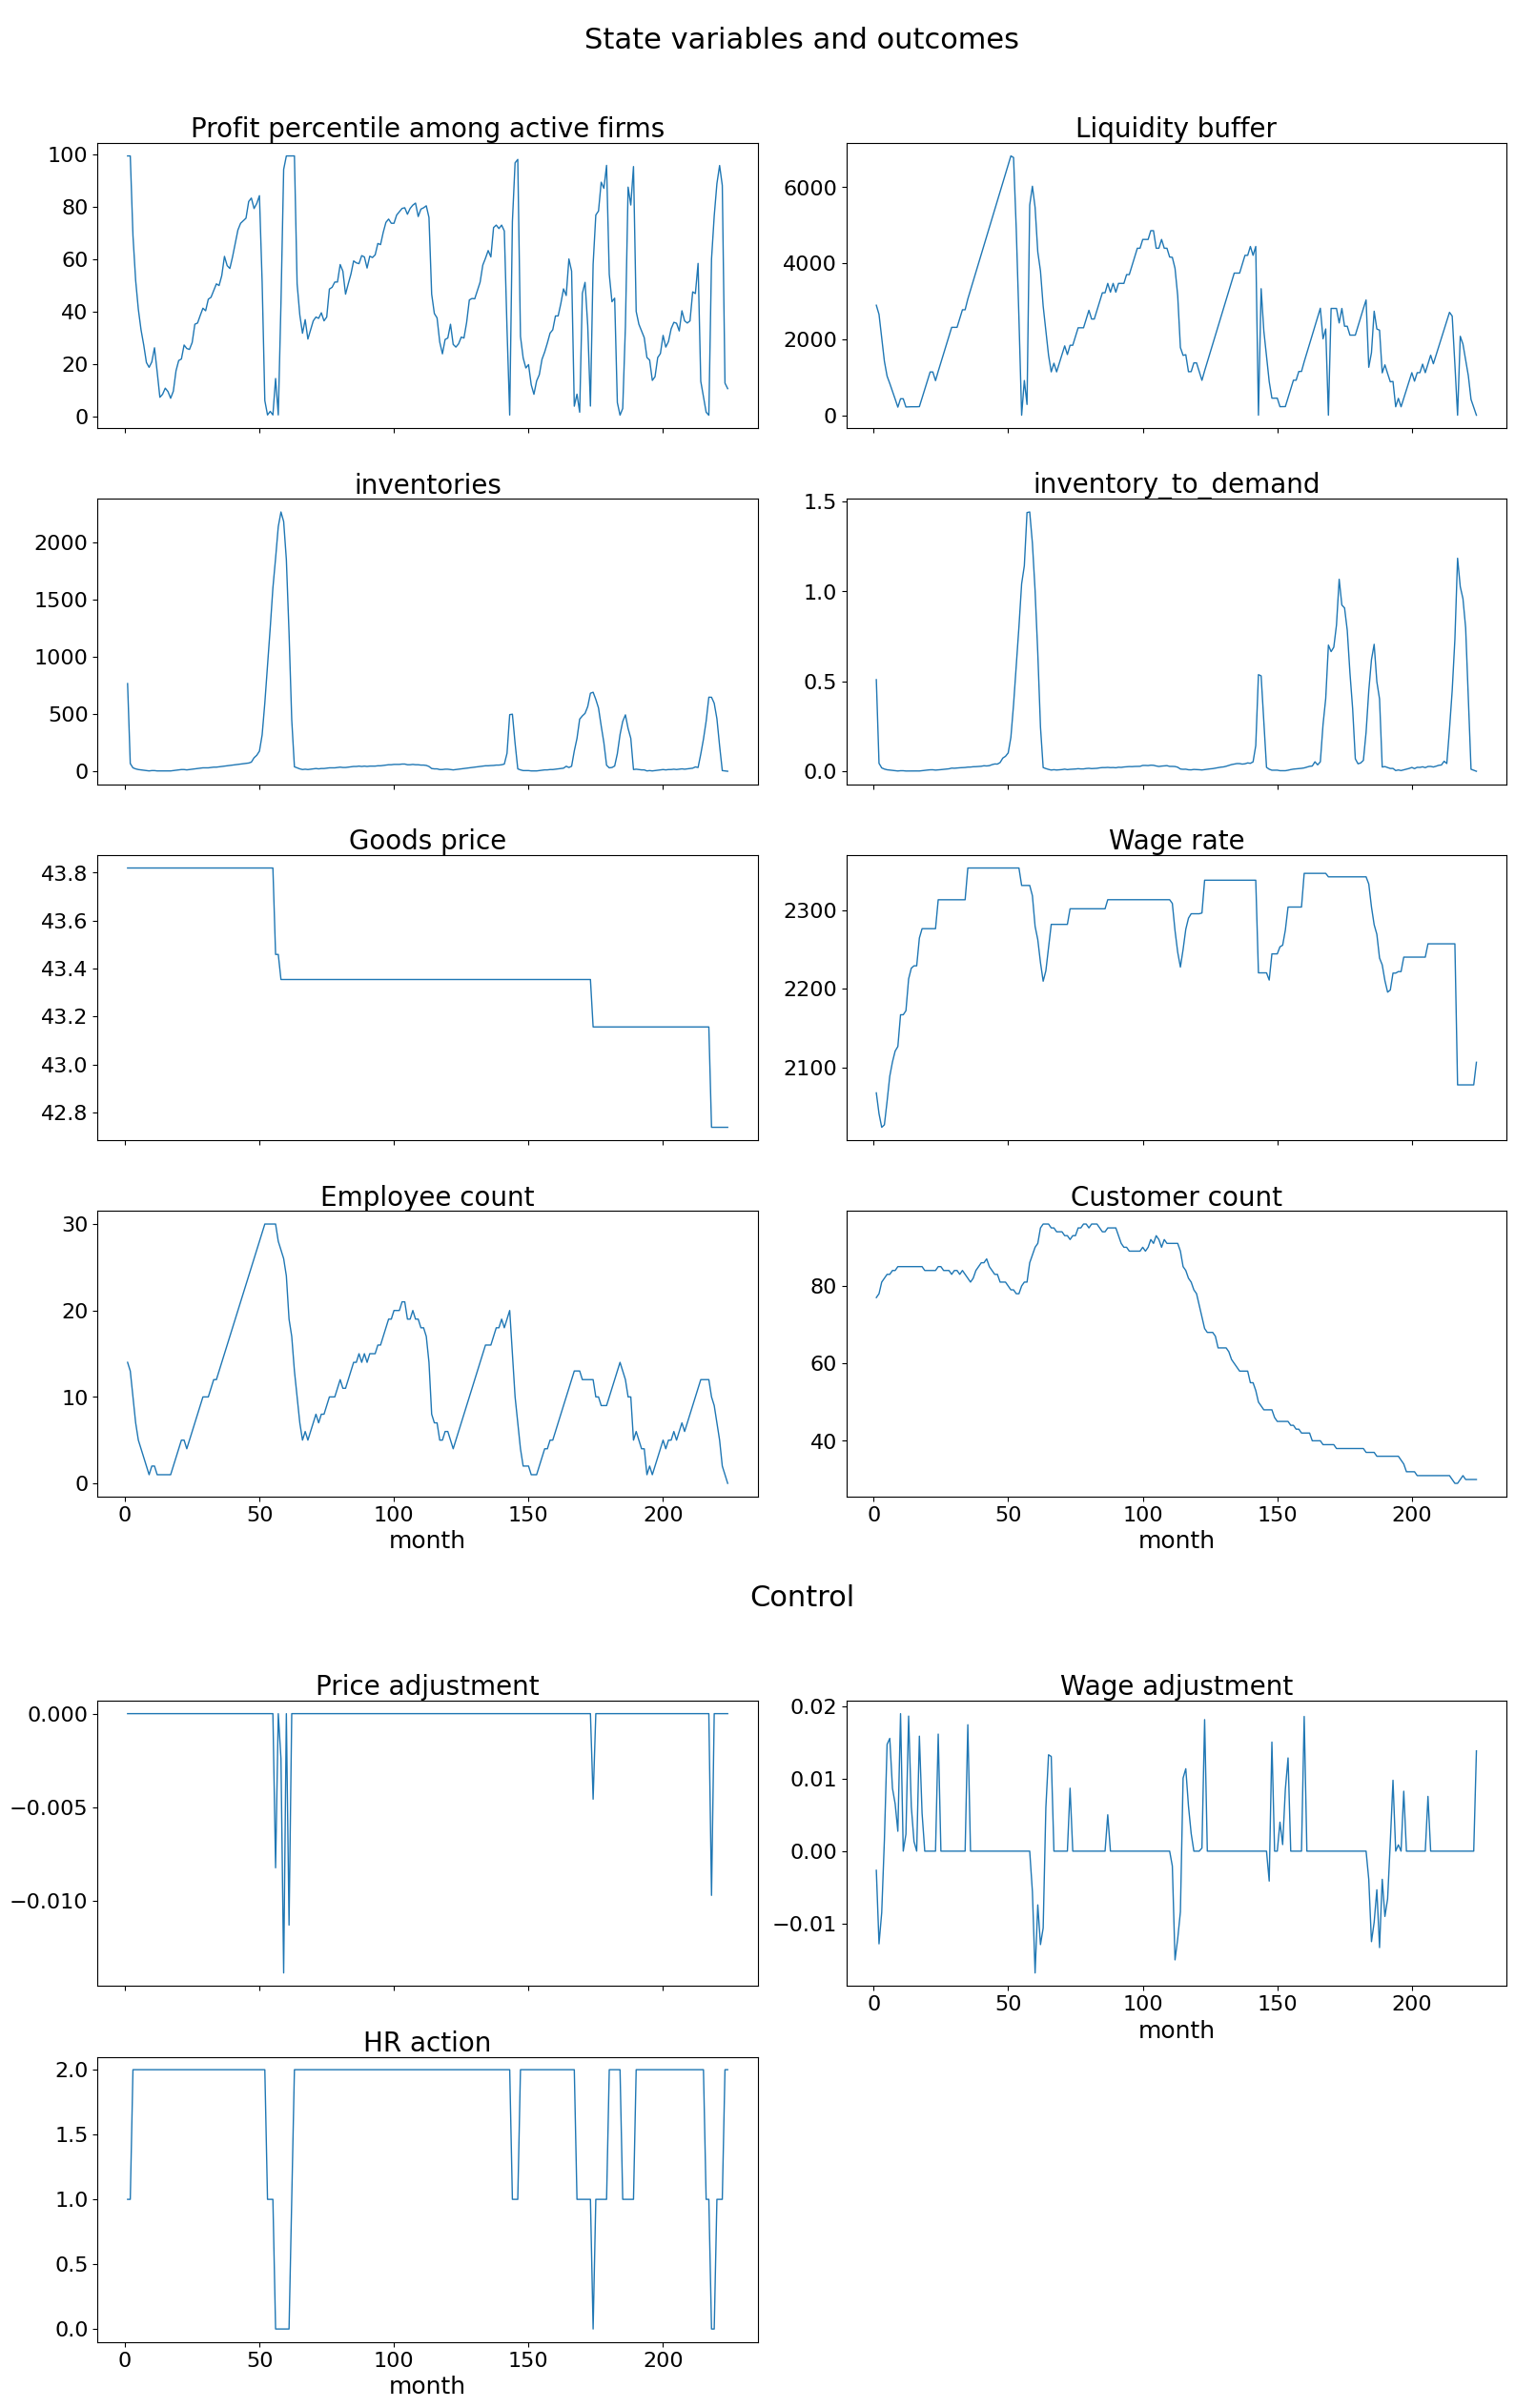

In [38]:
sections = {
    "State variables and outcomes": [
        "profit_percentiles",
        "liquidity_buffers",
        "inventories",
        "inventory_to_demand",
        "goods_prices",
        "wage_rates",
        "employee_counts",
        "customer_counts",
    ],
    "Control": [
        "price_adjustments",
        "wage_adjustments",
        "hr_actions",
    ],
}

plot_trajectories(
    baseline_stats[0],
    sections=sections,
    metric_labels=metric_labels,
    marker=None,
    panel_height=4.0,
    aspect=2.0,
    #transient_point=200,
    show_transient_note=False,
    download=False,
    #filename='fig_3.pdf'
)

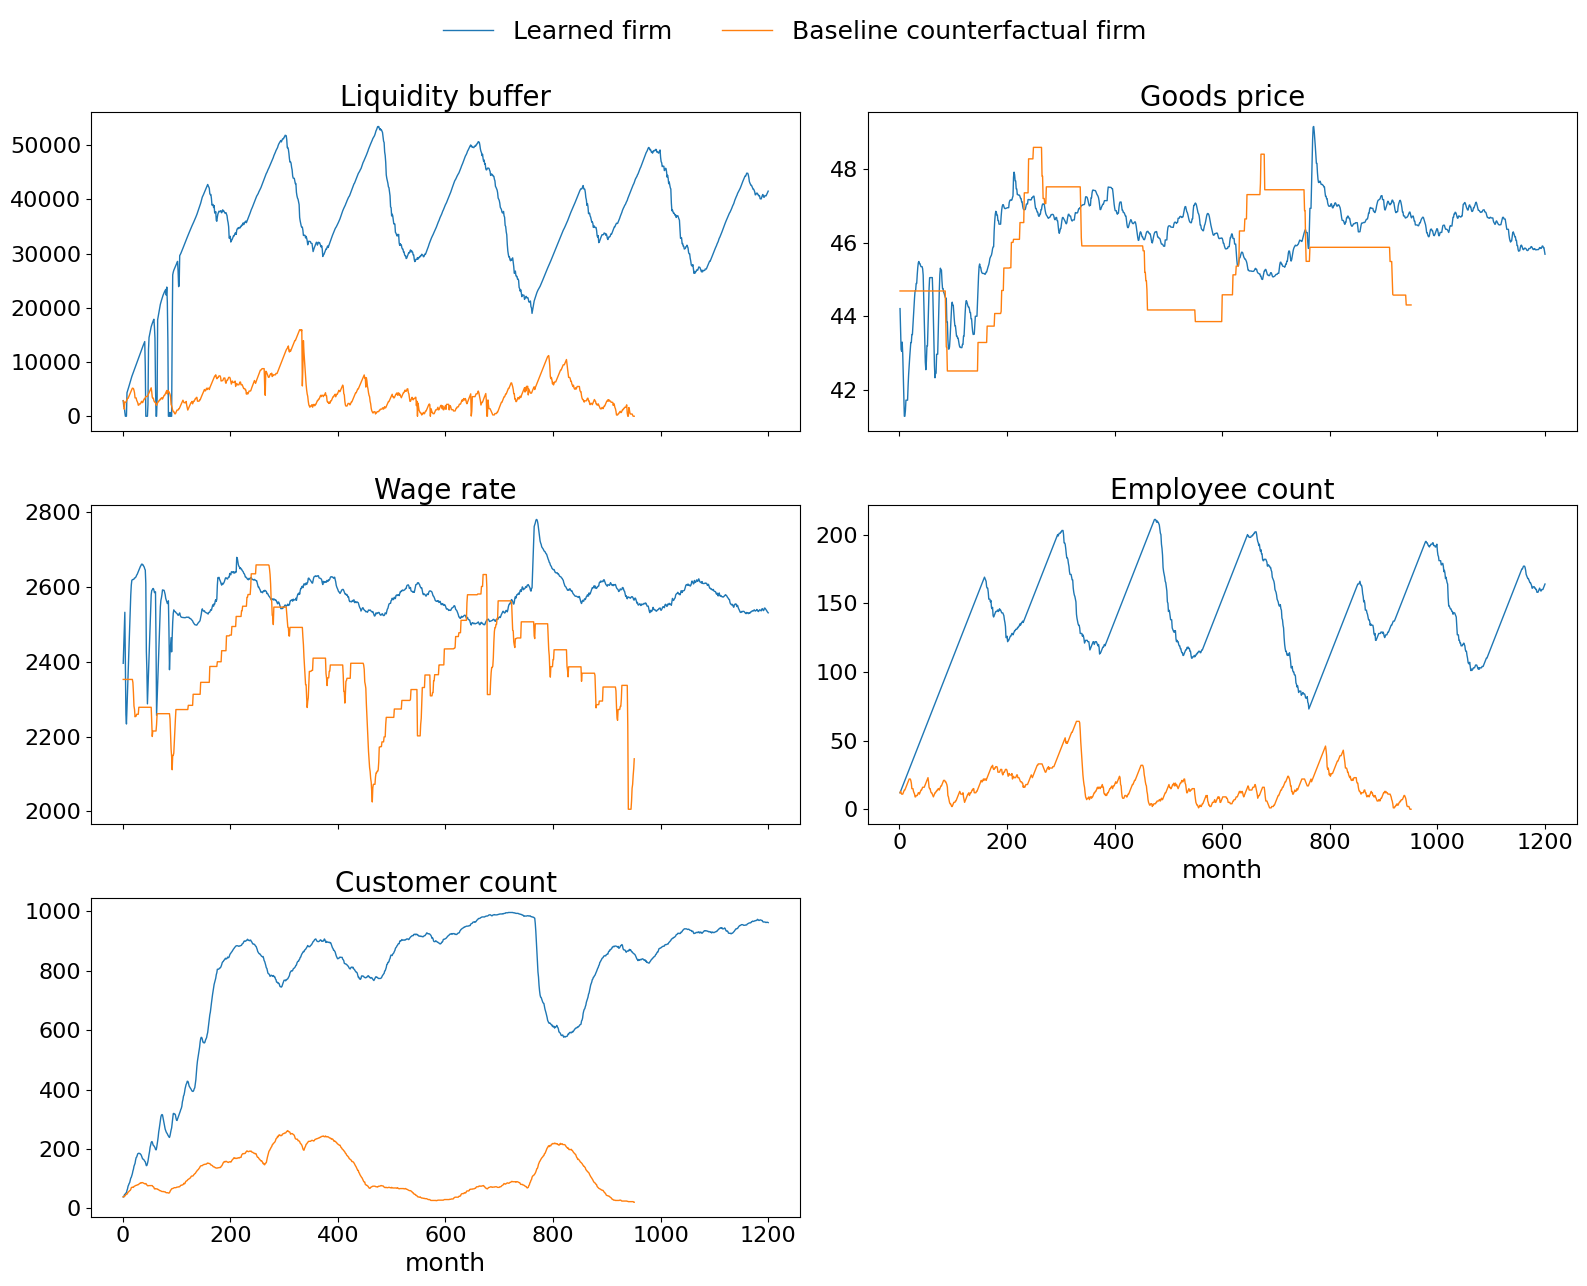

In [42]:
sections = {
    "State variables and outcome": [
        "liquidity_buffers",
        "goods_prices",
        "wage_rates",
        "employee_counts",
        "customer_counts",
        #"price_markups",
        #"median_active_prices",
        #"median_active_wages",
        #"median_active_customers",
        #"median_active_employees",
        #"active_firm_counts"
    ],
}

metric_labels = {
    "profit_percentiles": "Profit percentile among active firms",
    "liquidity_buffers": "Liquidity buffer",
    "goods_prices": "Goods price",
    "wage_rates": "Wage rate",
    "employee_counts": "Employee count",
    "customer_counts": "Customer count",
    "price_adjustments": "Price adjustment",
    "wage_adjustments": "Wage adjustment",
    "hr_actions": "HR action",
    "price_markups": "Price markup"
}

plot_trajectories_compare(
    stats_list=[stats[14], baseline_stats[14]],
    seed_labels=["Learned firm", "Baseline counterfactual firm"],
    sections=sections,
    metric_labels=metric_labels,
    show_suptitle=False,
    show_section_titles=False,
    download=True,
    filename="fig_6.pdf"
)

## Cross-seed summary

In [75]:
np.mean([cutoff for cutoff in TRANSIENT_CUTOFF.values() if cutoff is not None])

np.float64(145.0)

In [76]:
np.median([cutoff for cutoff in TRANSIENT_CUTOFF.values() if cutoff is not None])

np.float64(100.0)

In [77]:
np.std([cutoff for cutoff in TRANSIENT_CUTOFF.values() if cutoff is not None])

np.float64(80.7258735887489)

In [20]:
TRANSIENT_CUTOFF, STABLE_SEEDS

({20: 175,
  21: 200,
  22: 400,
  23: 100,
  24: 150,
  26: 100,
  27: 100,
  29: 100,
  30: None,
  31: 100,
  34: 100,
  35: 75,
  36: 150,
  37: 75,
  38: 125,
  39: 225},
 [20, 21, 22, 23, 24, 26, 27, 29, 31, 34, 35, 36, 37, 38, 39])

In [94]:
# Pre-transient stats
pre_stats = {}
# Post-transient stats
post_stats = {}
for seed in TRANSIENT_CUTOFF.keys():
    cutoff = TRANSIENT_CUTOFF[seed]
    pre_stats[seed] = {}
    pre_stats[seed]['mean_abs_wage_adjustment'] = np.mean(np.abs(stats[seed-20]['wage_adjustments'][:cutoff]))
    pre_stats[seed]['mean_abs_price_adjustment'] = np.mean(np.abs(stats[seed-20]['price_adjustments'][:cutoff]))
    pre_stats[seed]['mean_profit_percentile'] = np.mean(stats[seed-20]['profit_percentiles'][:cutoff])
    pre_stats[seed]['mean_employee_count'] = np.mean(stats[seed-20]['employee_counts'][:cutoff])
    pre_stats[seed]['mean_customer_count'] = np.mean(stats[seed-20]['customer_counts'][:cutoff])
    pre_stats[seed]['mean_liquidity_buffer'] = np.mean(stats[seed-20]['liquidity_buffers'][:cutoff])
    pre_stats[seed]['hr_actions'] = Counter(stats[seed-20]['hr_actions'][:cutoff])

    # Skip post stats if doesn't transition
    if cutoff is None:
        continue
    post_stats[seed] = {}
    post_stats[seed]['mean_abs_wage_adjustment'] = np.mean(np.abs(stats[seed-20]['wage_adjustments'][cutoff:]))
    post_stats[seed]['mean_abs_price_adjustment'] = np.mean(np.abs(stats[seed-20]['price_adjustments'][cutoff:]))
    post_stats[seed]['mean_profit_percentile'] = np.mean(stats[seed-20]['profit_percentiles'][cutoff:])
    post_stats[seed]['mean_employee_count'] = np.mean(stats[seed-20]['employee_counts'][cutoff:])
    post_stats[seed]['mean_customer_count'] = np.mean(stats[seed-20]['customer_counts'][cutoff:])
    post_stats[seed]['mean_liquidity_buffer'] = np.mean(stats[seed-20]['liquidity_buffers'][cutoff:])
    post_stats[seed]['hr_actions'] = Counter(stats[seed-20]['hr_actions'][cutoff:])

pre_mean_stats = {}
post_mean_stats = {}
for stat_name in ['mean_abs_wage_adjustment',
                  'mean_abs_price_adjustment',
                  'mean_profit_percentile',
                  'mean_employee_count',
                  'mean_customer_count',
                  'mean_liquidity_buffer']:
    pre_mean_stats[stat_name] = np.mean([stat[stat_name] for stat in pre_stats.values()])
    post_mean_stats[stat_name] = np.mean([stat[stat_name] for stat in post_stats.values()])

pd.DataFrame({
    'statistic': pre_mean_stats.keys(),
    'pre-transient': pre_mean_stats.values(),
    'post-transient': [post_mean_stats[k] for k in pre_mean_stats.keys()]
})

,statistic,pre-transient,post-transient
0,mean_abs_wage_adjustment,0.007451,0.001052
1,mean_abs_price_adjustment,0.004927,0.001206
2,mean_profit_percentile,58.629330,99.028702
3,mean_employee_count,49.281015,146.406903
4,mean_customer_count,189.494731,844.678531
5,mean_liquidity_buffer,11029.291046,37602.594617


In [106]:
pd.DataFrame({
    'seed': pre_stats.keys(),
    'pre-transient': [stat['hr_actions'] for stat in pre_stats.values()],
    'post-transient': [post_stats[seed]['hr_actions'] if seed in post_stats else None
                       for seed in pre_stats.keys()]
})

,seed,pre-transient,post-transient
0,20,{2: 175},{2: 1025}
1,21,{2: 200},{2: 1000}
2,22,{2: 400},{2: 800}
3,23,{2: 100},"{2: 1091, 1: 9}"
4,24,{2: 150},"{2: 1039, 1: 11}"
5,26,{2: 100},{2: 1100}
6,27,{2: 100},"{2: 1079, 1: 21}"
7,29,{2: 100},{2: 1100}
8,30,{2: 333},None
9,31,{2: 100},{2: 1100}


In [118]:
count_hire = 0
count_do_nothing = 0
count_fire = 0
for stat in post_stats.values():
    count_hire += stat['hr_actions'][2]
    count_do_nothing += stat['hr_actions'][1]
    count_fire += stat['hr_actions'][0]

print(count_hire, count_do_nothing, count_fire)
np.array([count_hire, count_do_nothing, count_fire]) / sum([count_hire, count_do_nothing, count_fire]) * 100

15719 106 0


array([99.33017378,  0.66982622,  0.        ])

## Save the stats

In [129]:
with open(os.path.join(os.path.abspath(os.path.join('..')), f'stats/learned_eval_results.pkl'), "wb") as f:
    pickle.dump((stats, models), f)

In [3]:
with open(os.path.join(os.path.abspath(os.path.join('..')), f'stats/baseline_eval_results_seeded.pkl'), "wb") as f:
    pickle.dump((baseline_stats, baseline_models), f)

NameError: name 'baseline_stats' is not defined

In [7]:
with open(os.path.join(os.path.abspath(os.path.join('..')), f'stats/learned_rounded_stats_0.pkl'), "rb") as f:
    stats = pickle.load(f)

In [11]:
with open(os.path.join(os.path.abspath(os.path.join('..')), f'stats/learned_eval_results.pkl'), "rb") as f:
    stats, models = pickle.load(f)

In [37]:
with open(os.path.join(os.path.abspath(os.path.join('..')), f'stats/baseline_eval_results_seeded.pkl'), "rb") as f:
    baseline_stats, baseline_models = pickle.load(f)